# Teste de Modelos de Machine Learning Global (Painel Multi-Série)


## Configuração Inicial (Setup)


In [1]:
import itertools
import json
import logging
import math
import os
import sys
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from typing import NamedTuple

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from dotenv import load_dotenv
from IPython.display import display
from joblib import Parallel, delayed, parallel_config
from lightgbm import LGBMRegressor, early_stopping
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
from tqdm import tqdm
from xgboost import XGBRegressor

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-04-01')  # first pandemic month: April 2020
COVID_END = pd.Timestamp('2021-12-31')
POST_COVID_START = pd.Timestamp('2022-01-01')
COVID_RECOVERY_END = pd.Timestamp('2022-06-30')

TARGET = 'arrival_count'  # original scale (arrivals)
Y = 'y'  # model scale (after the target processing)
TS_ID = 'series_id'
FREQ = 'ME'
SEASONAL_PERIOD = 12
RANDOM_STATE = 42

# physical cores: the fits are CPU-bound
N_JOBS = max(1, (os.cpu_count() or 2) // 2)

sns.set_palette('colorblind')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
logging.getLogger('mlflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=FutureWarning)
mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI'))
EXPERIMENT_NAME = 'Brazil Tourism Forecasting ML Global'
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

### Funções Auxiliares do Livro

Funções auxiliares do repositório complementar de Joseph & Tackes, *Modern Time Series Forecasting with Python* 2E.


In [2]:
# Helpers credited to: Joseph, M. & Tackes, J. "Modern Time Series Forecasting with
# Python", 2nd ed. (Packt, 2024) — MIT License
# github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E
MTSF_REPO_PATH = os.getenv(
    'MTSF_REPO_PATH',
    os.path.join(
        os.path.dirname(ROOT_PATH), 'Modern-Time-Series-Forecasting-with-Python-2E'
    ),
)
if MTSF_REPO_PATH not in sys.path:
    sys.path.insert(0, MTSF_REPO_PATH)

from src.feature_engineering.autoregressive_features import (  # noqa: E402
    add_lags,
    add_rolling_features,
    add_seasonal_rolling_features,
)
from src.feature_engineering.temporal_features import (  # noqa: E402
    add_fourier_features,
    add_temporal_features,
)
from src.forecasting.ml_forecasting import (  # noqa: E402
    FeatureConfig,
    MissingValueConfig,
    MLForecast,
    ModelConfig,
    calculate_metrics,
)

## 1. O Painel de Séries Temporais (Panel of Series)

O modelo global treina em um painel contendo todas as séries individuais (ex: por via de acesso, UF, etc.)
e reconstrói o total nacional por bottom-up (agregação).


In [3]:
ROUTES = {'Aérea': 'air', 'Terrestre': 'land'}
N_SUBDIVISIONS = 3
EXCLUDED_REGIONS = ['Outros']
MIN_MONTHLY_ARRIVALS = 1000
STATIC = ['route', 'region', 'subdivision', 'level']
SUBDIVISION_LABELS = {'Western / Eastern Europe': 'Europe'}


def load_rows(file_name):
    return pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))


train_rows = load_rows('train_ptbr.parquet')
rows = pd.concat([train_rows, load_rows('val_ptbr.parquet')], ignore_index=True)
TRAIN_END = train_rows['date'].max()
dates = pd.date_range(rows['date'].min(), rows['date'].max(), freq=FREQ)

top_subdivisions = (
    train_rows
    .groupby('country_cultural_subdivision')[TARGET]
    .sum()
    .nlargest(N_SUBDIVISIONS)
    .index.tolist()
)
candidates = rows[
    rows['access_route'].isin(ROUTES)
    & rows['country_cultural_subdivision'].isin(top_subdivisions)
    & ~rows['state_region'].isin(EXCLUDED_REGIONS)
]
components = (
    candidates
    .pivot_table(
        index=['access_route', 'state_region', 'country_cultural_subdivision'],
        columns='date',
        values=TARGET,
        aggfunc='sum',
    )
    .reindex(columns=dates, fill_value=0)
    .fillna(0)
)
recent_mean = components.loc[:, :TRAIN_END].iloc[:, -12:].mean(axis=1)
components = components[recent_mean >= MIN_MONTHLY_ARRIVALS]

total = rows.groupby('date')[TARGET].sum().reindex(dates)
remainder = total - components.sum()


def component_static(route, region, subdivision):
    return {
        'route': ROUTES[route],
        'region': region.replace('Região ', ''),
        'subdivision': SUBDIVISION_LABELS.get(subdivision, subdivision),
        'level': 'component',
    }


series_static = {}
series_values = {}
for key, values in components.iterrows():
    static = component_static(*key)
    series_id = f'{static["route"]}·{static["region"]}·{static["subdivision"]}'
    series_static[series_id] = static
    series_values[series_id] = values
for series_id, values in [('remainder', remainder), ('total', total)]:
    series_static[series_id] = {col: series_id for col in STATIC[:-1]} | {
        'level': series_id
    }
    series_values[series_id] = values

SERIES = list(series_values)
COMPONENTS = [s for s in SERIES if series_static[s]['level'] == 'component']
BOTTOM_UP = [*COMPONENTS, 'remainder']  # their sum is the total
STATIC_CATEGORIES = {
    col: sorted({static[col] for static in series_static.values()}) for col in STATIC
}

# one row per (series, month), contiguous per series
panel = pd.concat(
    [
        pd.DataFrame({'date': dates, TS_ID: series_id, TARGET: values.to_numpy()})
        for series_id, values in series_values.items()
    ],
    ignore_index=True,
)
panel_wide = panel.pivot_table(
    index='date', columns=TS_ID, values=TARGET, aggfunc='sum'
)[SERIES]
assert np.allclose(panel_wide[BOTTOM_UP].sum(axis=1), panel_wide['total'])

train_share = panel_wide.loc[:TRAIN_END]
summary = pd.DataFrame({
    'level': [series_static[s]['level'] for s in SERIES],
    'share of total (%)': (train_share.sum() / train_share['total'].sum() * 100).round(
        1
    ),
    'mean last 12 train months': train_share.iloc[-12:].mean().round(0),
    'zero months': (panel_wide == 0).sum(),
    'zero months since 2022': (panel_wide.loc[POST_COVID_START:] == 0).sum(),
})
print(
    f'Subdivisions: {top_subdivisions} | {len(COMPONENTS)} components + remainder + '
    f'total = {len(SERIES)} series × {len(dates)} months = {len(panel):,} rows'
)
print(
    f'Components cover {summary.loc[COMPONENTS, "share of total (%)"].sum():.1f}% of '
    'the training arrivals'
)
summary


Subdivisions: ['LATAM', 'Western / Eastern Europe', 'Anglo-America'] | 19 components + remainder + total = 21 series × 440 months = 9,240 rows
Components cover 86.2% of the training arrivals


,level,share of total (%),mean last 12 train months,zero months,zero months since 2022
series_id,,,,,
air·Centro-Oeste·Anglo-America,component,0.2,1686.0,101,0
air·Centro-Oeste·LATAM,component,0.2,1945.0,79,0
air·Centro-Oeste·Europe,component,0.2,1468.0,115,0
air·Nordeste·Anglo-America,component,0.3,1896.0,5,0
air·Nordeste·LATAM,component,1.0,7668.0,6,0
air·Nordeste·Europe,component,3.6,13143.0,3,0
air·Norte·Anglo-America,component,0.3,1510.0,5,0
air·Norte·LATAM,component,0.3,1236.0,3,0
air·Norte·Europe,component,0.2,1375.0,6,0


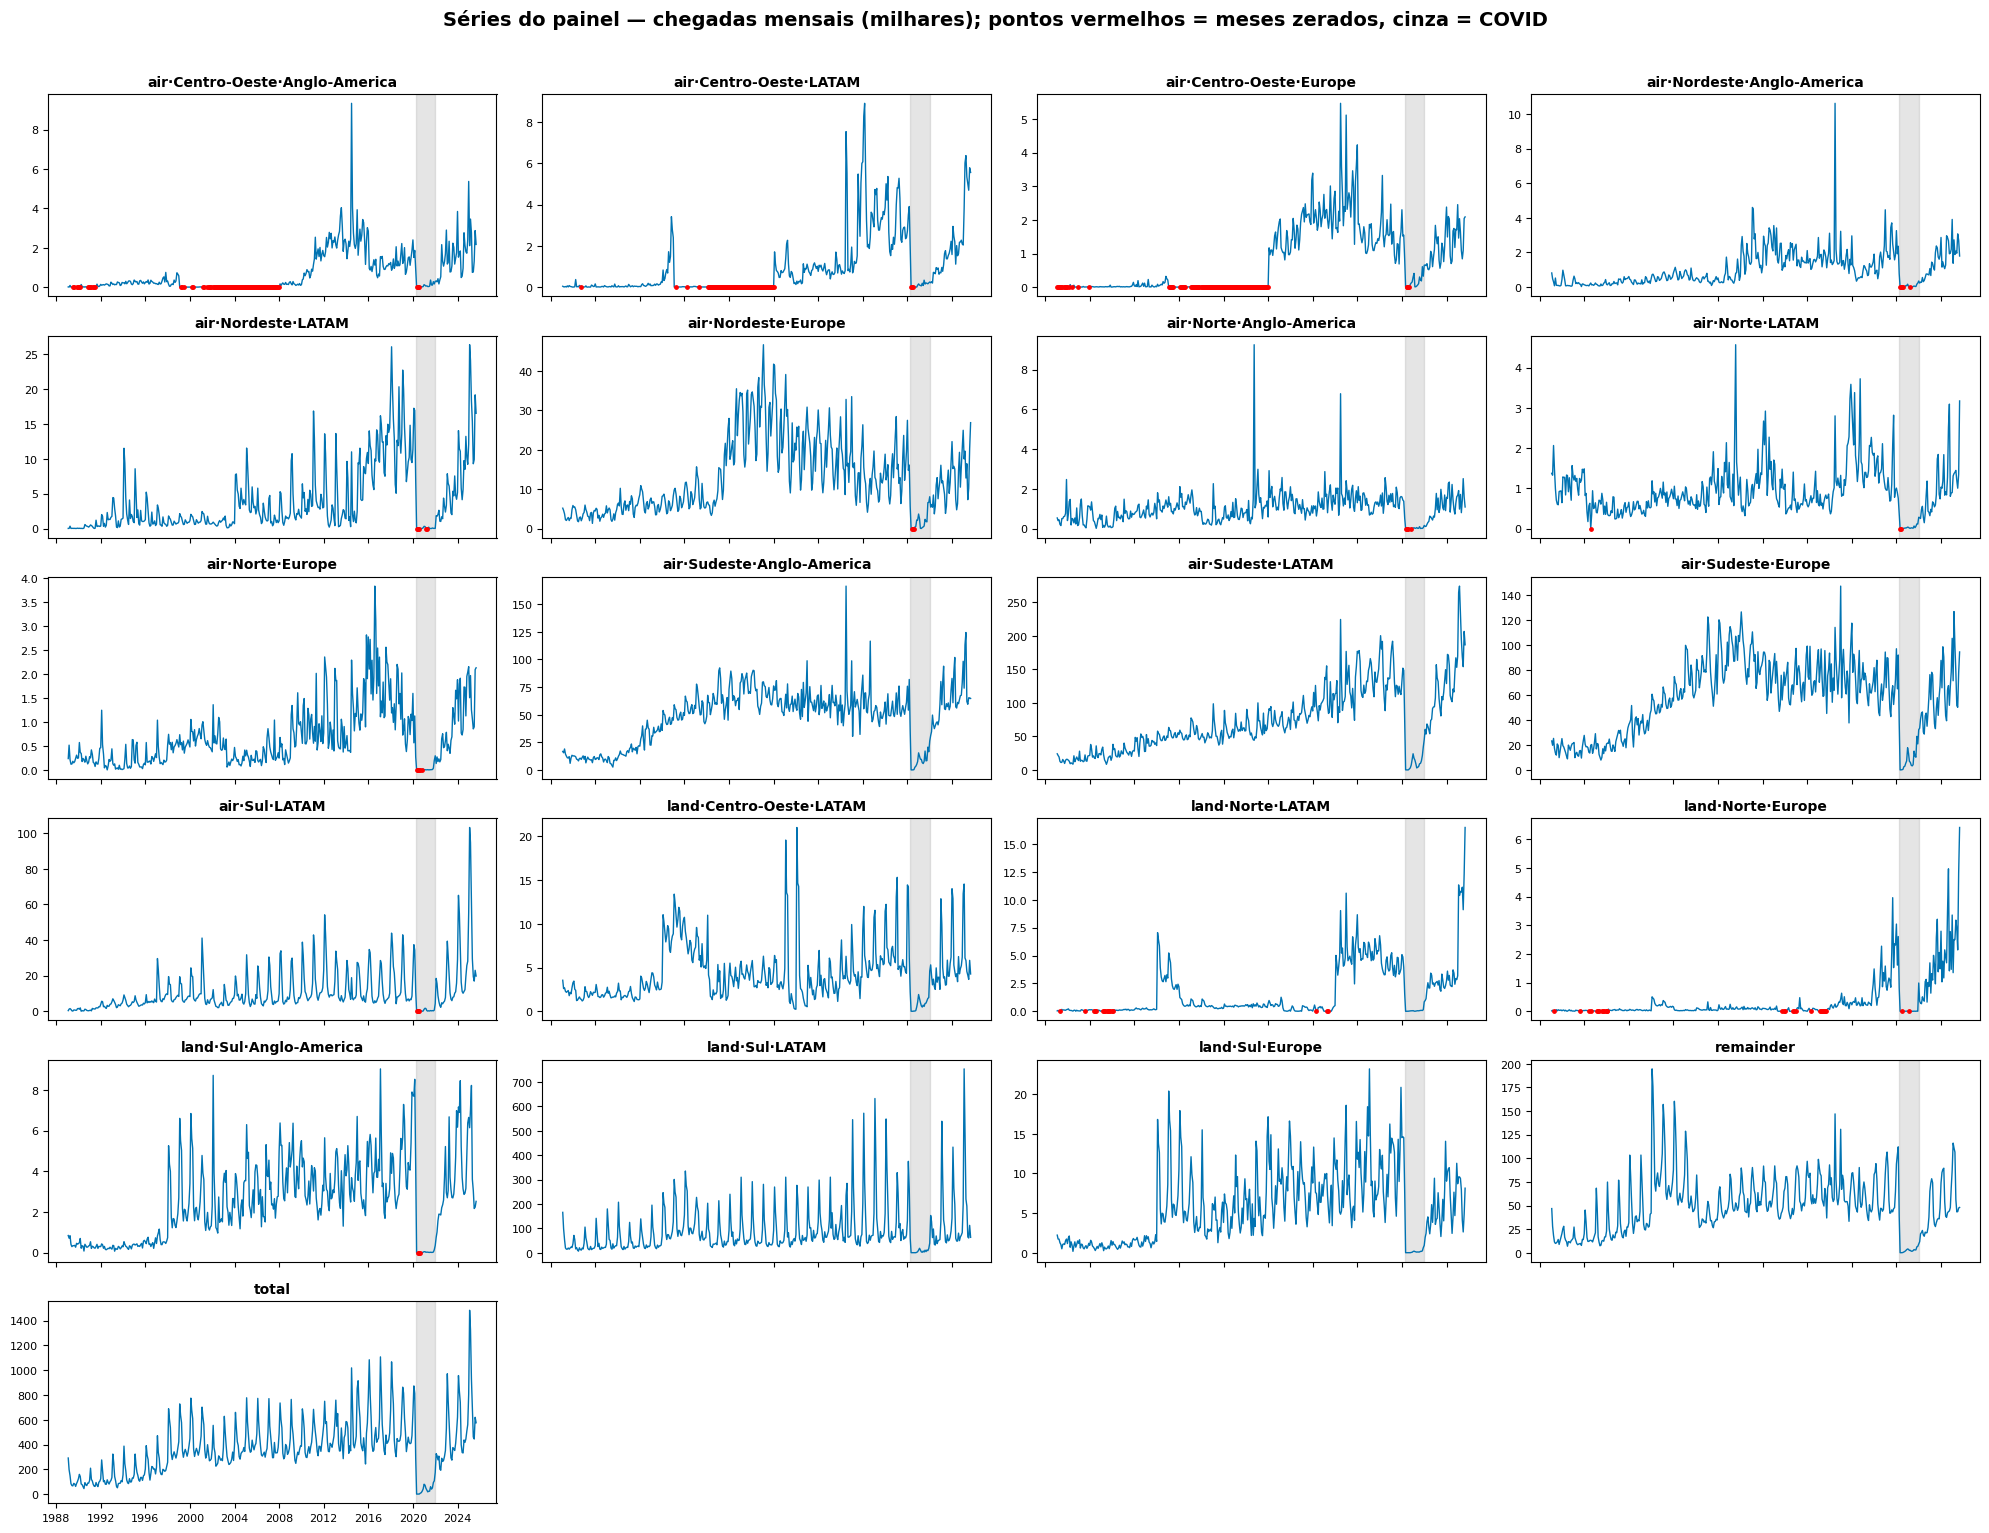

In [4]:
N_COLS = 4
n_rows = math.ceil(len(SERIES) / N_COLS)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(20, 2.6 * n_rows), sharex=True)
for ax, series_id in zip(axes.flat, SERIES):
    values = panel_wide[series_id]
    ax.plot(values.index, values / 1e3, linewidth=1)
    zeros = values[values == 0]
    ax.scatter(zeros.index, zeros, color='red', s=6, zorder=3)
    ax.axvspan(COVID_START, COVID_END, color='grey', alpha=0.2)
    ax.set_title(series_id, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)
for ax in axes.flat[len(SERIES) :]:
    ax.set_visible(False)
fig.suptitle(
    'Séries do painel — chegadas mensais (milhares); pontos vermelhos = meses zerados, cinza = COVID',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 2. Origens de Validação, Janelas, Linhas da COVID e Processamento de Alvo


In [5]:
HORIZON = 12
N_PRE_COVID_ORIGINS = 2
N_POST_COVID_ORIGINS = 2


def validation_window(origin):
    """First and last month forecast from `origin` (the last month the model sees)."""
    return origin + pd.offsets.MonthEnd(1), origin + pd.offsets.MonthEnd(HORIZON)


n_train_months = len(panel_wide.loc[:TRAIN_END])
candidates = [TRAIN_END] + [
    TRAIN_END - pd.offsets.MonthEnd(12 * k) for k in range(1, n_train_months // 12)
]
post_covid_origins = [o for o in candidates if validation_window(o)[0] > COVID_END][
    :N_POST_COVID_ORIGINS
]
pre_covid_origins = [o for o in candidates if validation_window(o)[1] < COVID_START][
    :N_PRE_COVID_ORIGINS
]
ORIGINS = sorted(pre_covid_origins + post_covid_origins)
LATEST_ORIGIN = TRAIN_END  # its validation window is val.parquet
assert LATEST_ORIGIN in ORIGINS
assert validation_window(LATEST_ORIGIN)[1] == dates[-1]


def origin_label(origin):
    return f'{origin:%Y-%m}'


def val_dates_at(origin):
    start, end = validation_window(origin)
    return panel_wide.loc[start:end].index


WINDOWS = {'all': None, 'last_10y': 10, 'last_6y': 6}
REMOVED_START = pd.Timestamp('2020-01-31')
REMOVED_END = pd.Timestamp('2022-12-31')
COVID_ROWS = ['keep', 'remove']


def window_start(window, origin):
    years = WINDOWS[window]
    return dates[0] if years is None else origin - pd.DateOffset(years=years)


def effective_covid_rows(covid_rows, origin):
    """Before the pandemic there is nothing to remove: `remove` equals `keep`."""
    return 'keep' if origin < REMOVED_START else covid_rows


def training_panel(covid_rows, origin):
    """The panel up to the origin, without the removed years for `remove`."""
    part = panel[panel['date'] <= origin]
    if covid_rows == 'remove':
        part = part[~part['date'].between(REMOVED_START, REMOVED_END)]
    return part.reset_index(drop=True)


pd.DataFrame([
    {
        'origin': origin_label(origin),
        'phase': 'pre-COVID' if origin < COVID_START else 'post-COVID',
        'validation window': f'{start:%b %Y} → {end:%b %Y}',
        'history months': len(panel_wide.loc[:origin]),
    }
    for origin in ORIGINS
    for start, end in [validation_window(origin)]
])

,origin,phase,validation window,history months
0,2017-08,pre-COVID,Sep 2017 → Aug 2018,344
1,2018-08,pre-COVID,Sep 2018 → Aug 2019,356
2,2023-08,post-COVID,Sep 2023 → Aug 2024,416
3,2024-08,post-COVID,Sep 2024 → Aug 2025,428


In [6]:
TARGET_TRANSFORMS = ['log', 'seasonal_log_diff', 'mean_scale']


class Log1pTarget:
    """log(1 + y); inverse exp(z) - 1."""

    @staticmethod
    def transform(y):
        return np.log1p(y.astype(float))

    @staticmethod
    def inverse_transform(z):
        return np.expm1(np.asarray(z, dtype=float))


class SeasonalLog1pDiffTarget:
    """z_t = log(1 + y_t) - log(1 + y_{t-12}), positional (notebook 7, with log1p).

    The inverse takes y_{t-12} from the last `period` months of the fitted history, so
    it is exact for forecasts up to `period` months after the end of that history.
    """

    def __init__(self, history, period=SEASONAL_PERIOD):
        self.period = period
        self.log_history = np.log1p(history.astype(float)).to_numpy()
        self.last_date = history.index[-1]

    def transform(self, y):
        log_y = np.log1p(y.astype(float))
        return log_y - log_y.shift(self.period)

    def inverse_transform(self, z, dates):
        dates = pd.DatetimeIndex(dates)
        steps = (dates.year - self.last_date.year) * 12 + (
            dates.month - self.last_date.month
        )
        assert ((steps >= 1) & (steps <= self.period)).all(), 'up to one season ahead'
        base = self.log_history[len(self.log_history) - self.period + steps - 1]
        return np.expm1(np.asarray(z, dtype=float) + base)


class MeanScaleTarget:
    """y / m, with m the mean of the last 12 months of the fitted history."""

    def __init__(self, history):
        self.scale = max(float(history.iloc[-SEASONAL_PERIOD:].mean()), 1.0)

    def transform(self, y):
        return y.astype(float) / self.scale

    def inverse_transform(self, z):
        return np.asarray(z, dtype=float) * self.scale


def fit_target_transform(name, history):
    if name == 'log':
        return Log1pTarget()
    if name == 'seasonal_log_diff':
        return SeasonalLog1pDiffTarget(history)
    if name == 'mean_scale':
        return MeanScaleTarget(history)
    raise ValueError(f'unknown target transform: {name}')


def inverse(transformer, z, dates):
    if isinstance(transformer, SeasonalLog1pDiffTarget):
        return transformer.inverse_transform(z, dates)
    return transformer.inverse_transform(z)


def make_setup(transform_name, covid_rows, origin):
    """Per-series transformers and the model-scale panel history of one origin."""
    part = training_panel(covid_rows, origin)
    transformers, history = {}, []
    for series_id, frame in part.groupby(TS_ID, sort=False):
        values = frame.set_index('date')[TARGET]
        transformers[series_id] = fit_target_transform(transform_name, values)
        history.append(
            frame.assign(**{Y: transformers[series_id].transform(values).to_numpy()})
        )
    return {
        'origin': origin,
        'transform': transform_name,
        'covid_rows': covid_rows,
        'transformers': transformers,
        'history': pd.concat(history, ignore_index=True)[['date', TS_ID, Y, TARGET]],
    }


setups = {
    (origin, name, covid_rows): make_setup(name, covid_rows, origin)
    for origin in ORIGINS
    for name in TARGET_TRANSFORMS
    for covid_rows in COVID_ROWS
    if effective_covid_rows(covid_rows, origin) == covid_rows
}
print(f'{len(setups)} setups (origin × target processing × COVID rows)')

18 setups (origin × target processing × COVID rows)


## 3. Construtor de Features para o Painel


In [7]:
with open(os.path.join(DATA_FOLDER_PATH, 'feature_groups_ptbr.json'), encoding='utf-8') as f:
    FEATURE_SPEC = json.load(f)
PARAMS = FEATURE_SPEC['parameters']
SEASONAL_LAGS = [
    lag
    for lag in FEATURE_SPEC['strategies']['recursive']['lags']
    if lag >= SEASONAL_PERIOD
]

GROUP_ORDER = [
    'lags',
    'growth',
    'rolling',
    'domain',
    'static',
    'cal_cat',
    'cal_fourier',
]
TARGET_DERIVED = ['lags', 'growth', 'rolling']
CATEGORICAL_GROUPS = ['static', 'cal_cat']


def lags_for_shift(shift):
    """The two most recent legal lags plus the seasonal lags that are still legal."""
    return sorted({shift, shift + 1} | {lag for lag in SEASONAL_LAGS if lag >= shift})


def growth_lags_for_shift(shift):
    return sorted({shift} | ({SEASONAL_PERIOD} if SEASONAL_PERIOD >= shift else set()))


def add_ewma_per_series(df, column, spans, n_shift):
    """`add_ewma` (book) computed inside each series, with the book's column names."""
    by_series = df.groupby(TS_ID)[column]
    added = {
        f'{column}_ewma_span_{span}': by_series.transform(
            lambda x, span=span: x.shift(n_shift).ewm(span=span, adjust=False).mean()
        )
        for span in spans
    }
    return df.assign(**added), list(added)


def is_spliced(df):
    """True when the removed COVID years are missing from the history."""
    return (
        not df['date'].between(REMOVED_START, REMOVED_END).any()
        and (df['date'] > REMOVED_END).any()
    )


def add_domain_features(df, lags):
    df['days_in_month'] = df['date'].dt.days_in_month
    if is_spliced(df):
        # a lag crosses the gap when the row is after it and the lagged row before it
        df['is_pre_gap'] = (df['date'] < REMOVED_START).astype(int)
        df, pre_gap_lags = add_lags(df, lags=lags, column='is_pre_gap', ts_id=TS_ID)
        after_gap = (df['date'] > REMOVED_END).astype(int)
        flags = []
        for lag, column in zip(lags, pre_gap_lags):
            flag = f'crosses_gap_lag_{lag}'
            df[flag] = (df[column].fillna(1) * after_gap).astype(int)
            flags.append(flag)
        return df, ['days_in_month', *flags]
    df['is_covid'] = df['date'].between(COVID_START, COVID_END).astype(int)
    df['is_covid_recovery'] = (
        df['date'].between(POST_COVID_START, COVID_RECOVERY_END).astype(int)
    )
    df, covid_lags = add_lags(df, lags=lags, column='is_covid', ts_id=TS_ID)
    df[covid_lags] = df[covid_lags].fillna(0).astype(int)
    return df, ['is_covid', 'is_covid_recovery', 'days_in_month', *covid_lags]


def add_static_features(df):
    for col in STATIC:
        values = df[TS_ID].map(lambda s, col=col: series_static[s][col])
        df[col] = pd.Categorical(values, categories=STATIC_CATEGORIES[col])
    return df, list(STATIC)


def build_features(df, shift):
    """Every feature group, per series, for a model that knows the target `shift` back.

    `df` has `date`, `series_id`, `y` (model scale) and `arrival_count` (arrivals).
    Future rows have NaN targets. Returns the feature table (sorted by series and date)
    and {group: [columns]}.
    """
    df = df.sort_values([TS_ID, 'date']).reset_index(drop=True)
    groups = {}
    lags = lags_for_shift(shift)

    # target-derived groups (book helpers, per series)
    df, groups['lags'] = add_lags(df, lags=lags, column=Y, ts_id=TS_ID)
    previous = df.groupby(TS_ID)[TARGET].shift(1)
    df['arrivals_mom_growth'] = (df[TARGET] / previous - 1).replace(
        [np.inf, -np.inf], np.nan
    )
    df, groups['growth'] = add_lags(
        df, lags=growth_lags_for_shift(shift), column='arrivals_mom_growth', ts_id=TS_ID
    )
    df, rolling = add_rolling_features(
        df,
        rolls=PARAMS['rolling_windows'],
        column=Y,
        agg_funcs=PARAMS['rolling_aggs'],
        ts_id=TS_ID,
        n_shift=shift,
    )
    df, seasonal = add_seasonal_rolling_features(
        df,
        seasonal_periods=[PARAMS['seasonal_period']],
        rolls=PARAMS['seasonal_windows'],
        column=Y,
        agg_funcs=PARAMS['seasonal_aggs'],
        ts_id=TS_ID,
        n_shift=math.ceil(shift / PARAMS['seasonal_period']),  # counted in seasons
    )
    df, ewma = add_ewma_per_series(df, Y, PARAMS['ewma_spans'], shift)
    groups['rolling'] = rolling + seasonal + ewma

    # calendar groups (book helpers)
    df, _ = add_temporal_features(
        df,
        field_name='date',
        frequency=FREQ,
        add_elapsed=True,
        prefix='cal',
        drop=False,
    )
    df, groups['cal_fourier'] = add_fourier_features(
        df,
        column_to_encode='cal_Month',
        max_value=12,
        n_fourier_terms=PARAMS['fourier_terms'],
    )
    df['cal_Month'] = pd.Categorical(df['cal_Month'], categories=range(1, 13))
    groups['cal_cat'] = ['cal_Month']

    df, groups['domain'] = add_domain_features(df, lags)
    df, groups['static'] = add_static_features(df)
    return df, groups


def training_rows(features, groups, start, end):
    """Rows of the training window with a known target and complete target features."""
    target_derived = [c for g in TARGET_DERIVED for c in groups[g]]
    rows = features[features['date'].between(start, end)]
    return rows.dropna(subset=[Y, *target_derived])


example, example_groups = build_features(
    setups[LATEST_ORIGIN, 'log', 'keep']['history'], shift=1
)
display(
    pd.DataFrame({
        'n_columns': {g: len(example_groups[g]) for g in GROUP_ORDER},
        'columns': {g: ', '.join(example_groups[g][:6]) for g in GROUP_ORDER},
    })
)
example[example['date'] == LATEST_ORIGIN][
    ['date', TS_ID, TARGET, Y, f'{Y}_lag_12', f'{Y}_ewma_span_3', *STATIC]
].head(6)


,n_columns,columns
lags,6,"y_lag_1, y_lag_2, y_lag_12, y_lag_13, y_lag_24..."
growth,2,"arrivals_mom_growth_lag_1, arrivals_mom_growth..."
rolling,19,"y_rolling_3_mean, y_rolling_3_std, y_rolling_3..."
domain,9,"is_covid, is_covid_recovery, days_in_month, is..."
static,4,"route, region, subdivision, level"
cal_cat,1,cal_Month
cal_fourier,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."


,date,series_id,arrival_count,y,y_lag_12,y_ewma_span_3,route,region,subdivision,level
427,2024-08-31,air·Centro-Oeste·Anglo-America,2128.0,7.663408,7.611348,7.325877,air,Centro-Oeste,Anglo-America,component
855,2024-08-31,air·Centro-Oeste·Europe,1747.0,7.466228,7.066467,7.094649,air,Centro-Oeste,Europe,component
1283,2024-08-31,air·Centro-Oeste·LATAM,2176.0,7.685703,7.337588,7.399641,air,Centro-Oeste,LATAM,component
1711,2024-08-31,air·Nordeste·Anglo-America,2678.0,7.893199,7.727094,7.760078,air,Nordeste,Anglo-America,component
2139,2024-08-31,air·Nordeste·Europe,19346.0,9.870293,9.604610,9.203143,air,Nordeste,Europe,component
2567,2024-08-31,air·Nordeste·LATAM,8495.0,9.047351,8.453188,8.909425,air,Nordeste,LATAM,component


### Conjuntos de Features, Configuração e Valores Ausentes


In [8]:
FEATURE_SETS = [
    ('lags', 'rolling', 'domain', 'static', 'cal_fourier'),
    ('lags', 'rolling', 'domain', 'static', 'cal_cat'),
    ('lags', 'growth', 'rolling', 'domain', 'static', 'cal_fourier'),
]


def canonical(feature_set):
    """Order the groups of a feature set consistently."""
    return tuple(g for g in GROUP_ORDER if g in feature_set)


def set_label(feature_set):
    return '+'.join(canonical(feature_set))


def categorical_columns(groups, feature_set):
    return [col for g in CATEGORICAL_GROUPS if g in feature_set for col in groups[g]]


def make_feature_config(groups, feature_set):
    continuous = [
        col
        for g in canonical(feature_set)
        if g not in CATEGORICAL_GROUPS
        for col in groups[g]
    ]
    return FeatureConfig(
        date='date',
        target=Y,
        original_target=TARGET,
        continuous_features=continuous,
        categorical_features=categorical_columns(groups, feature_set),
        index_cols=['date', TS_ID],
    )


def make_missing_config(groups):
    return MissingValueConfig(
        bfill_columns=groups['lags'] + groups['growth'] + groups['rolling']
    )

## 4. Famílias de Modelos


In [9]:
FAMILIES = ['ridge', 'lasso', 'lightgbm', 'xgboost']
FAMILY_NAMES = {
    'ridge': 'Ridge',
    'lasso': 'Lasso',
    'lightgbm': 'LightGBM',
    'xgboost': 'XGBoost',
}
TREE_FAMILIES = {'lightgbm', 'xgboost'}

CV_SPLITS = 5
CV_TEST_MONTHS = 12
RIDGE_ALPHAS = np.logspace(-3, 3, 13)

N_TREES = 2000
LGBM_PARAMS = {
    'n_estimators': N_TREES,
    'learning_rate': 0.02,
    'num_leaves': 8,
    'min_child_samples': 10,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.8,
    'random_state': RANDOM_STATE,
    'n_jobs': 1,
    'verbose': -1,
}
XGB_PARAMS = {
    'n_estimators': N_TREES,
    'learning_rate': 0.02,
    'max_depth': 3,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'enable_categorical': True,
    'random_state': RANDOM_STATE,
    'n_jobs': 1,
}
EARLY_STOPPING_ROUNDS = 100
EARLY_STOPPING_MONTHS = 12  # the last 12 months of every series in the window
MIN_MONTHS_FOR_EARLY_STOPPING = 3 * EARLY_STOPPING_MONTHS
SHORT_WINDOW_TREES = 300


class MLForecastFixed(MLForecast):
    """Book MLForecast with the predict-time column check on the *input* columns."""

    def fit(self, X, y, is_transformed=False, fit_kwargs=None):
        self._input_features = X.columns.tolist()
        return super().fit(
            X, y, is_transformed=is_transformed, fit_kwargs=fit_kwargs or {}
        )

    def predict(self, X):
        missing = set(self._input_features) - set(X.columns)
        assert not missing, f'features missing at prediction time: {missing}'
        X = X[self._input_features].copy()
        if self.model_config.fill_missing:
            X = self.missing_config.impute_missing_values(X)
        if self.model_config.encode_categorical:
            X = self._cat_encoder.transform(X)
        if self.model_config.normalize:
            scaled = self._continuous_feats + self._encoded_categorical_features
            X[scaled] = self._scaler.transform(X[scaled])
        return pd.Series(
            self._model.predict(X[self._train_features]).ravel(),
            index=X.index,
            name=f'{self.model_config.name}',
        )


def temporal_cv(n_months, n_series):
    """TimeSeriesSplit on month-sorted rows: folds of ~12 months of every series."""
    n_splits = max(2, min(CV_SPLITS, n_months // CV_TEST_MONTHS - 1))
    test_months = min(CV_TEST_MONTHS, n_months // (n_splits + 1))
    return TimeSeriesSplit(n_splits=n_splits, test_size=test_months * n_series)


def make_estimator(family, n_months, n_series, tree_params=None):
    if family == 'ridge':
        return RidgeCV(alphas=RIDGE_ALPHAS, cv=temporal_cv(n_months, n_series))
    if family == 'lasso':
        return LassoCV(alphas=30, cv=temporal_cv(n_months, n_series), max_iter=20000)
    if family == 'lightgbm':
        return LGBMRegressor(**{**LGBM_PARAMS, **(tree_params or {})})
    return XGBRegressor(**{**XGB_PARAMS, **(tree_params or {})})


def make_model_config(family, categorical, shape, tree_params=None):  # noqa: PLR0917
    """A fresh ModelConfig (book) for one fit; `shape` = (months, series)."""
    is_tree = family in TREE_FAMILIES
    encode = bool(categorical) and not is_tree
    return ModelConfig(
        model=make_estimator(family, *shape, tree_params),
        name=FAMILY_NAMES[family],
        normalize=not is_tree,
        fill_missing=not is_tree,
        encode_categorical=encode,
        categorical_encoder=OneHotEncoder(cols=categorical) if encode else None,
    )


def feature_matrix(feature_config, rows):
    """`get_X_y` (book) with the columns in a fixed, sorted order."""
    X, y, _ = feature_config.get_X_y(rows, categorical=True)
    return X[sorted(X.columns)], y


def best_n_estimators(  # noqa: PLR0913, PLR0917
    family, feature_config, missing_config, X, y, tree_params
):
    """Early stopping on the last 12 months of every series (never on validation)."""
    months = X.index.get_level_values('date')
    holdout = months > np.sort(months.unique())[-EARLY_STOPPING_MONTHS - 1]
    shape = (months[~holdout].nunique(), X.index.get_level_values(TS_ID).nunique())
    probe_config = make_model_config(
        family, feature_config.categorical_features, shape, tree_params
    )
    eval_set = [(X[holdout], y[holdout])]
    if family == 'lightgbm':
        fit_kwargs = {
            'eval_set': eval_set,
            'callbacks': [early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
        }
    else:
        probe_config.model.set_params(early_stopping_rounds=EARLY_STOPPING_ROUNDS)
        fit_kwargs = {'eval_set': eval_set, 'verbose': False}
    probe = MLForecastFixed(
        model_config=probe_config,
        feature_config=feature_config,
        missing_config=missing_config,
    )
    probe.fit(X[~holdout], y[~holdout], fit_kwargs=fit_kwargs)
    if family == 'lightgbm':
        return probe._model.best_iteration_ or N_TREES
    return probe._model.best_iteration + 1


def fit_model(family, feature_config, missing_config, train, tree_params=None):
    """Chapter 8's `evaluate_model` (fit part) on month-sorted panel rows."""
    train = train.sort_values(['date', TS_ID])
    X, y = feature_matrix(feature_config, train)
    y = y[Y]
    shape = (train['date'].nunique(), train[TS_ID].nunique())
    model_config = make_model_config(
        family, feature_config.categorical_features, shape, tree_params
    )
    if family in TREE_FAMILIES:
        n_trees = (
            best_n_estimators(family, feature_config, missing_config, X, y, tree_params)
            if shape[0] >= MIN_MONTHS_FOR_EARLY_STOPPING
            else SHORT_WINDOW_TREES
        )
        model_config.model.set_params(n_estimators=n_trees)
    model = MLForecastFixed(
        model_config=model_config,
        feature_config=feature_config,
        missing_config=missing_config,
    )
    model.fit(X, y)
    return model


def model_info(family, model):
    """Tree count, or chosen penalty and whether it sits on the edge of its grid."""
    estimator = model._model
    if family in TREE_FAMILIES:
        return {'n_trees': int(estimator.get_params()['n_estimators'])}
    grid = np.asarray(estimator.alphas if family == 'ridge' else estimator.alphas_)
    alpha = float(estimator.alpha_)
    return {
        'alpha': alpha,
        'alpha_at_edge': bool(
            np.isclose(alpha, grid.min()) or np.isclose(alpha, grid.max())
        ),
    }


def predict_rows(model, feature_config, rows):
    X, _ = feature_matrix(feature_config, rows)
    return model.predict(X)

## 5. Estratégias Multi-step no Painel


In [10]:
STRATEGIES = ['recursive', 'direct_single']


class Config(NamedTuple):
    family: str
    transform: str
    window: str
    covid_rows: str
    strategy: str
    feature_set: tuple

    @property
    def label(self):
        return (
            f'{FAMILY_NAMES[self.family]} | {self.transform} | {self.window} | '
            f'{self.covid_rows} | {self.strategy} | {set_label(self.feature_set)}'
        )


def to_arrivals(setup, predicted_z):
    """Inverse-transform a long frame (date, series_id, z) to arrivals, per series."""
    out = predicted_z.copy()
    for series_id, frame in predicted_z.groupby(TS_ID):
        out.loc[frame.index, TARGET] = inverse(
            setup['transformers'][series_id], frame['z'], frame['date']
        )
    return out


def with_future_rows(history, future_dates):
    future = pd.DataFrame(
        [(d, s) for s in SERIES for d in future_dates], columns=['date', TS_ID]
    ).assign(**{Y: np.nan, TARGET: np.nan})
    return pd.concat([history, future], ignore_index=True)


def fit_for_shift(config, setup, frame, shift, tree_params=None):  # noqa: PLR0917
    features, groups = build_features(frame, shift)
    feature_config = make_feature_config(groups, config.feature_set)
    origin = setup['origin']
    model = fit_model(
        config.family,
        feature_config,
        make_missing_config(groups),
        training_rows(features, groups, window_start(config.window, origin), origin),
        tree_params,
    )
    return model, feature_config, features


def predicted_frame(model, feature_config, rows):
    z = predict_rows(model, feature_config, rows)
    return pd.DataFrame({
        'date': z.index.get_level_values('date'),
        TS_ID: z.index.get_level_values(TS_ID),
        'z': z.to_numpy(),
    })


def forecast_recursive(config, setup, future_dates, tree_params=None):
    model, feature_config, _ = fit_for_shift(
        config, setup, setup['history'], 1, tree_params
    )
    extended = setup['history']
    steps = []
    for date in future_dates:
        extended = with_future_rows(extended, [date])
        features, _ = build_features(extended, 1)
        step = to_arrivals(
            setup,
            predicted_frame(model, feature_config, features[features['date'] == date]),
        )
        # feed the predictions back: model scale and arrivals, per series
        fed = step.set_index(TS_ID)
        is_new = extended['date'] == date
        extended.loc[is_new, Y] = extended.loc[is_new, TS_ID].map(fed['z']).to_numpy()
        extended.loc[is_new, TARGET] = (
            extended.loc[is_new, TS_ID].map(fed[TARGET]).to_numpy()
        )
        steps.append(step)
    return pd.concat(steps, ignore_index=True), model


def forecast_direct_single(config, setup, future_dates, tree_params=None):
    extended = with_future_rows(setup['history'], future_dates)
    model, feature_config, features = fit_for_shift(
        config, setup, extended, len(future_dates), tree_params
    )
    rows = features[features['date'].isin(future_dates)]
    return to_arrivals(setup, predicted_frame(model, feature_config, rows)), model


FORECASTERS = {
    'recursive': forecast_recursive,
    'direct_single': forecast_direct_single,
}

### Avaliação de uma Configuração


In [11]:
METRICS = ['RMSE', 'MAE', 'MAPE', 'R2', 'MASE', 'Forecast Bias']
AGG_METRICS = [
    'MASE_mean',
    'MASE_worst',
    'MASE_post',
    'MASE_direct_mean',
    'MASE_series_mean',
    'n_origins',
]
# seasonal differences distorted by the pandemic collapse and rebound
MASE_EXCLUDED = (COVID_START, pd.Timestamp('2022-12-31'))


def seasonal_mase_scale(history):
    """In-sample MAE of the seasonal naive (y_t - y_{t-12}), pandemic pairs excluded."""
    diffs = (history - history.shift(SEASONAL_PERIOD)).abs()
    in_pandemic = history.index.to_series().between(*MASE_EXCLUDED)
    touches = in_pandemic | in_pandemic.shift(SEASONAL_PERIOD, fill_value=False)
    return float(diffs[~touches.to_numpy()].mean())


MASE_SCALES = {
    origin: {s: seasonal_mase_scale(panel_wide.loc[:origin, s]) for s in SERIES}
    for origin in ORIGINS
}


def score_total(actual, predicted, name, origin):
    metrics = calculate_metrics(
        actual, predicted, name
    )  # book: MAE, MSE, Forecast Bias
    errors = (actual - predicted).to_numpy()
    return {
        'RMSE': float(np.sqrt(metrics['MSE'])),
        'MAE': metrics['MAE'],
        'MAPE': float(np.mean(np.abs(errors / actual.to_numpy())) * 100),
        'R2': float(r2_score(actual.to_numpy(), predicted.to_numpy())),
        'MASE': float(metrics['MAE'] / MASE_SCALES[origin]['total']),
        'Forecast Bias': metrics['Forecast Bias'],
        'abs_errors': np.abs(errors),
    }


def score_forecast(forecast, name, origin):
    """Scores of one origin's forecast table (index = month, one column per series)."""
    actual = panel_wide.loc[forecast.index]
    series_mase = {
        s: float(np.mean(np.abs(actual[s] - forecast[s])) / MASE_SCALES[origin][s])
        for s in SERIES
    }
    bottom_up = forecast[BOTTOM_UP].sum(axis=1)
    direct_mae = float(np.mean(np.abs(actual['total'] - forecast['total'])))
    return {
        **score_total(actual['total'], bottom_up, name, origin),
        'MASE_direct': direct_mae / MASE_SCALES[origin]['total'],
        'MASE_series': float(np.mean([series_mase[s] for s in BOTTOM_UP])),
        'series_mase': series_mase,
        'prediction': bottom_up.to_numpy(),
        'forecast': {s: forecast[s].to_numpy() for s in SERIES},
    }


def aggregate(per_origin):
    """Combine the per-origin scores of one configuration ({origin: scores})."""
    mase = pd.Series({origin: s['MASE'] for origin, s in per_origin.items()})
    post = mase[mase.index.isin(post_covid_origins)]
    latest = per_origin.get(LATEST_ORIGIN, {})
    return {
        'MASE_mean': float(mase.mean()),
        'MASE_worst': float(mase.max()),
        'MASE_post': float(post.mean()) if len(post) else np.nan,
        'MASE_direct_mean': float(
            np.mean([s['MASE_direct'] for s in per_origin.values()])
        ),
        'MASE_series_mean': float(
            np.mean([s['MASE_series'] for s in per_origin.values()])
        ),
        'n_origins': len(mase),
        # the latest origin forecasts the validation year (val.parquet)
        **{key: latest.get(key, np.nan) for key in METRICS},
    }


def setup_for(config, origin):
    covid_rows = effective_covid_rows(config.covid_rows, origin)
    return setups[origin, config.transform, covid_rows]


def forecast_table(config, origin, tree_params=None):
    predicted, model = FORECASTERS[config.strategy](
        config, setup_for(config, origin), val_dates_at(origin), tree_params
    )
    table = predicted.pivot_table(
        index='date', columns=TS_ID, values=TARGET, aggfunc='first'
    )[SERIES]
    if not np.all(np.isfinite(table.to_numpy())):
        raise ValueError('non-finite forecast after the inverse transform')
    return table, model


def evaluate_at(config, origin, tree_params=None):
    """Fit, forecast and score one configuration at one origin (worker process)."""
    result = {'origin': origin}
    start = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        try:
            table, model = forecast_table(config, origin, tree_params)
            result.update(score_forecast(table, config.family, origin))
            result.update(model_info(config.family, model))
            result['error'] = None
        except Exception as exc:  # noqa: BLE001 — reported in the results table
            result['error'] = f'{type(exc).__name__}: {exc}'[:250]
    result['fit_seconds'] = time.perf_counter() - start
    return result


def config_origins(config):
    return list(ORIGINS)


def summarize(config, origin_results, tree_params=None):
    """One results row per configuration: the origins aggregated."""
    row = {**config._asdict(), 'feature_set': set_label(config.feature_set)}
    ok = {r['origin']: r for r in origin_results if r['error'] is None}
    errors = [r['error'] for r in origin_results if r['error'] is not None]
    row['error'] = errors[0] if errors else None
    row['fit_seconds'] = sum(r['fit_seconds'] for r in origin_results)
    row['origin_mase'] = {origin: r['MASE'] for origin, r in ok.items()}
    if not errors:
        row.update(aggregate(ok))
    latest = ok.get(LATEST_ORIGIN, {})
    for key in [
        'prediction',
        'abs_errors',
        'forecast',
        'series_mase',
        'n_trees',
        'alpha',
    ]:
        if key in latest:
            row[key] = latest[key]
    edges = [r['alpha_at_edge'] for r in ok.values() if 'alpha_at_edge' in r]
    if edges:
        row['alpha_at_edge'] = f'{sum(edges)}/{len(edges)}'
    row['tuned'] = tree_params is not None
    row['tree_params'] = tree_params
    return row


example_config = Config(
    'lightgbm', 'seasonal_log_diff', 'all', 'keep', 'direct_single', FEATURE_SETS[0]
)
example = evaluate_at(example_config, LATEST_ORIGIN)
assert example['error'] is None, example['error']
print(example_config.label)
print(
    f'Validation year: bottom-up MASE {example["MASE"]:.3f} | '
    f'direct MASE {example["MASE_direct"]:.3f} | '
    f'series MASE {example["MASE_series"]:.3f}'
)
pd.DataFrame(
    {
        'actual total': panel_wide.loc[val_dates_at(LATEST_ORIGIN), 'total'],
        'bottom-up': example['prediction'],
        'direct': example['forecast']['total'],
    },
).round(0)

LightGBM | seasonal_log_diff | all | keep | direct_single | lags+rolling+domain+static+cal_fourier
Validation year: bottom-up MASE 4.165 | direct MASE 4.305 | series MASE 2.615


,actual total,bottom-up,direct
date,,,
2024-09-30,445389.0,368956.0,342695.0
2024-10-31,508738.0,405390.0,396175.0
2024-11-30,560732.0,500602.0,487478.0
2024-12-31,806478.0,625470.0,603237.0
2025-01-31,1483669.0,978559.0,996498.0
2025-02-28,1326884.0,837774.0,819146.0
2025-03-31,929096.0,705674.0,698434.0
2025-04-30,686239.0,391392.0,392785.0
2025-05-31,461341.0,317830.0,315741.0


## 6. Linhas de Base (Baselines)


In [12]:
def baseline_forecast(origin, seasonal):
    history = panel_wide.loc[:origin]
    future = val_dates_at(origin)
    if seasonal:
        values = history.reindex(future - pd.offsets.MonthEnd(12)).to_numpy()
    else:
        values = np.tile(history.iloc[-1].to_numpy(), (len(future), 1))
    return pd.DataFrame(values, index=future, columns=SERIES)


baseline_scores = {
    name: {o: score_forecast(baseline_forecast(o, seasonal), name, o) for o in ORIGINS}
    for name, seasonal in [('naive', False), ('seasonal_naive', True)]
}
baselines = pd.DataFrame({
    name: aggregate(per_origin) for name, per_origin in baseline_scores.items()
}).T
BASELINE_MASE = float(baselines.loc['seasonal_naive', 'MASE_mean'])
baseline_forecasts = {
    name: scores[LATEST_ORIGIN]['prediction']
    for name, scores in baseline_scores.items()
}

display(
    pd.DataFrame({
        name: {origin_label(o): s['MASE'] for o, s in per_origin.items()}
        for name, per_origin in baseline_scores.items()
    }).rename_axis('seasonal MASE of the total by origin')
)
baselines[[*AGG_METRICS, *METRICS]].astype(float).round(3)

,naive,seasonal_naive
seasonal MASE of the total by origin,,
2017-08,3.325103,0.680184
2018-08,2.441616,0.977196
2023-08,3.393431,1.462635
2024-08,6.148383,4.023995


,MASE_mean,MASE_worst,MASE_post,MASE_direct_mean,MASE_series_mean,n_origins,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
naive,3.827,6.148,4.771,3.827,2.937,4.0,460440.495,319530.000,33.968,-0.929,6.148,43.328
seasonal_naive,1.786,4.024,2.743,1.786,1.950,4.0,255353.116,209126.083,26.478,0.407,4.024,28.357


## 7. Busca em Grade (Grid Search)


In [13]:
configs = [
    Config(*choices)
    for choices in itertools.product(
        FAMILIES, TARGET_TRANSFORMS, WINDOWS, COVID_ROWS, STRATEGIES, FEATURE_SETS
    )
]


def task_key(config, origin):
    """Before the pandemic `remove` is the same model as `keep`: share the task."""
    return config._replace(
        covid_rows=effective_covid_rows(config.covid_rows, origin)
    ), origin


tasks = list(
    dict.fromkeys(
        task_key(config, origin)
        for config in configs
        for origin in config_origins(config)
    )
)
print(
    f'{len(configs)} configurations × their origins → {len(tasks)} fits '
    f'on {N_JOBS} workers...'
)

grid_start = time.perf_counter()
with parallel_config(backend='loky', inner_max_num_threads=1):
    outputs = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(evaluate_at)(config, origin) for config, origin in tasks
    )
print(f'Fitting done in {time.perf_counter() - grid_start:,.0f}s')

by_task = dict(zip(tasks, outputs))
results = [
    summarize(config, [by_task[task_key(config, o)] for o in config_origins(config)])
    for config in configs
]
results_df = pd.DataFrame(results)
failed = results_df[results_df['error'].notna()]
print(f'Failed: {len(failed)} / {len(results_df)}')
if len(failed):
    display(failed['error'].str.split(':').str[0].value_counts().rename('failures'))

432 configurations × their origins → 1296 fits on 8 workers...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:  1.5min
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:  3.0min
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:  3.9min
[Parallel(n_jobs=8)]: Done 272 tasks      | elapsed:  4.8min
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:  5.6min
[Parallel(n_jobs=8)]: Done 632 tasks      | elapsed:  6.6min
[Parallel(n_jobs=8)]: Done 866 tasks      | elapsed:  8.1min
[Parallel(n_jobs=8)]: Done 1136 tasks      | elapsed: 13.2min
[Parallel(n_jobs=8)]: Done 1296 out of 1296 | elapsed: 16.5min finished


Fitting done in 993s
Failed: 0 / 432


## 8. Resultados


In [14]:
PARAM_KEYS = ['family', 'transform', 'window', 'covid_rows', 'strategy', 'feature_set']


def rank(frame):
    ranked = (
        frame[frame['error'].isna()].sort_values('MASE_mean').reset_index(drop=True)
    )
    ranked['beats_seasonal_naive'] = ranked['MASE_mean'] < BASELINE_MASE
    return ranked


ranked = rank(results_df)
print(
    f'{len(ranked)} configurations ranked; '
    f'{ranked["beats_seasonal_naive"].sum()} beat the seasonal naive '
    f'(mean seasonal MASE {BASELINE_MASE:.3f})'
)
ranked[[*PARAM_KEYS, *AGG_METRICS, 'RMSE', 'MAPE', 'fit_seconds']].head(15).round(3)

432 configurations ranked; 113 beat the seasonal naive (mean seasonal MASE 1.786)


,family,transform,window,covid_rows,strategy,feature_set,MASE_mean,MASE_worst,MASE_post,MASE_direct_mean,MASE_series_mean,n_origins,RMSE,MAPE,fit_seconds
0,ridge,mean_scale,all,remove,recursive,lags+rolling+domain+static+cal_cat,1.467,2.677,1.969,1.380,1.802,4,221859.836,14.002,18.778
1,ridge,mean_scale,all,remove,recursive,lags+rolling+domain+static+cal_fourier,1.473,2.673,1.955,1.394,1.795,4,222250.647,13.931,26.363
2,ridge,mean_scale,all,remove,recursive,lags+growth+rolling+domain+static+cal_fourier,1.473,2.665,1.951,1.394,1.794,4,221566.769,13.888,20.286
3,lightgbm,seasonal_log_diff,last_10y,remove,recursive,lags+rolling+domain+static+cal_cat,1.481,3.018,2.059,1.553,1.764,4,204502.803,19.398,17.115
4,lightgbm,seasonal_log_diff,all,remove,recursive,lags+growth+rolling+domain+static+cal_fourier,1.493,3.235,2.105,1.572,1.715,4,222864.827,20.045,19.301
5,xgboost,seasonal_log_diff,all,remove,recursive,lags+growth+rolling+domain+static+cal_fourier,1.496,3.212,2.079,1.489,1.711,4,223837.167,19.772,80.185
6,lasso,seasonal_log_diff,all,remove,recursive,lags+rolling+domain+static+cal_cat,1.500,3.141,1.924,1.517,1.665,4,213299.200,19.696,12.797
7,lasso,seasonal_log_diff,last_10y,remove,recursive,lags+rolling+domain+static+cal_cat,1.504,3.607,2.263,1.596,1.765,4,232455.023,23.699,15.355
8,lightgbm,seasonal_log_diff,all,remove,recursive,lags+rolling+domain+static+cal_cat,1.507,3.090,2.027,1.454,1.727,4,210704.594,19.507,23.449
9,ridge,seasonal_log_diff,last_10y,remove,recursive,lags+rolling+domain+static+cal_fourier,1.508,2.455,2.288,1.761,1.921,4,165774.791,16.735,14.438


### Ajuste Fino dos Modelos de Árvore (Optuna)


In [15]:
N_TRIALS = 25
optuna.logging.set_verbosity(optuna.logging.WARNING)

DEFAULT_TRIAL = {
    'lightgbm': {
        'num_leaves': 8,
        'min_child_samples': 10,
        'reg_alpha': 1e-3,
        'reg_lambda': 1e-3,
        'objective': 'regression',
        'linear_tree': False,
    },
    'xgboost': {
        'max_depth': 3,
        'min_child_weight': 3.0,
        'reg_alpha': 1e-3,
        'reg_lambda': 1.0,
        'objective': 'reg:squarederror',
    },
}


def suggest_tree_params(trial, family):
    regularization = {
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
    }
    if family == 'lightgbm':
        params = {
            'num_leaves': trial.suggest_int('num_leaves', 4, 32, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 3, 30),
            'objective': trial.suggest_categorical(
                'objective', ['regression', 'regression_l1', 'huber']
            ),
            'linear_tree': trial.suggest_categorical('linear_tree', [False, True]),
            **regularization,
        }
        if params['linear_tree'] and params['objective'] == 'regression_l1':
            raise optuna.TrialPruned('LightGBM cannot fit linear trees with an L1 loss')
        return params
    return {
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'min_child_weight': trial.suggest_float('min_child_weight', 1, 20, log=True),
        'objective': trial.suggest_categorical(
            'objective',
            ['reg:squarederror', 'reg:absoluteerror', 'reg:pseudohubererror'],
        ),
        **regularization,
    }


def evaluate_origins(config, tree_params):
    with parallel_config(backend='loky', inner_max_num_threads=1):
        return Parallel(n_jobs=min(N_JOBS, len(ORIGINS)))(
            delayed(evaluate_at)(config, origin, tree_params)
            for origin in config_origins(config)
        )


def row_config(row):
    return Config(
        row['family'],
        row['transform'],
        row['window'],
        row['covid_rows'],
        row['strategy'],
        canonical(row['feature_set'].split('+')),
    )


def tune(config):
    def objective(trial):
        tree_params = suggest_tree_params(trial, config.family)
        origin_results = evaluate_origins(config, tree_params)
        if any(r['error'] is not None for r in origin_results):
            raise optuna.TrialPruned('failed at an origin')
        return float(np.mean([r['MASE'] for r in origin_results]))

    study = optuna.create_study(
        direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.enqueue_trial(DEFAULT_TRIAL[config.family])
    study.optimize(objective, n_trials=N_TRIALS)
    tree_params = dict(study.best_params)
    return study, summarize(config, evaluate_origins(config, tree_params), tree_params)


tune_start = time.perf_counter()
grid_rows = ranked[~ranked['tuned']]
studies, tuned_rows = {}, []
for family in sorted(TREE_FAMILIES):
    for window in WINDOWS:
        group = grid_rows[
            (grid_rows['family'] == family) & (grid_rows['window'] == window)
        ]
        if group.empty:
            continue
        studies[family, window], tuned_row = tune(row_config(group.iloc[0]))
        tuned_rows.append(tuned_row)
print(
    f'Tuned {len(studies)} family × window groups in '
    f'{time.perf_counter() - tune_start:,.0f}s'
)

results_df = pd.concat([results_df, pd.DataFrame(tuned_rows)], ignore_index=True)
ranked = rank(results_df)

tuning = pd.DataFrame([
    {
        'family': FAMILY_NAMES[family],
        'window': window,
        'configuration': row_config(tuned_row).label,
        'grid MASE_mean': study.trials[0].value,
        'tuned MASE_mean': study.best_value,
        'gain': study.trials[0].value - study.best_value,
        'trials (complete / pruned)': (
            f'{sum(t.state.name == "COMPLETE" for t in study.trials)} / '
            f'{sum(t.state.name == "PRUNED" for t in study.trials)}'
        ),
        'best parameters': study.best_params,
    }
    for ((family, window), study), tuned_row in zip(studies.items(), tuned_rows)
])
display(tuning.round(3))
display(
    tuning
    .pivot_table(index='window', columns='family', values='tuned MASE_mean')
    .reindex(index=[w for w in WINDOWS if w in set(tuning['window'])])
    .rename_axis('tuned MASE_mean')
    .round(3)
)

Tuned 6 family × window groups in 988s


,family,window,configuration,grid MASE_mean,tuned MASE_mean,gain,trials (complete / pruned),best parameters
0,LightGBM,all,LightGBM | seasonal_log_diff | all | remove | ...,1.514,1.414,0.101,25 / 0,"{'reg_alpha': 0.016739707398215068, 'reg_lambd..."
1,LightGBM,last_10y,LightGBM | seasonal_log_diff | last_10y | remo...,1.499,1.478,0.021,25 / 0,"{'reg_alpha': 0.001584726827332143, 'reg_lambd..."
2,LightGBM,last_6y,LightGBM | seasonal_log_diff | last_6y | keep ...,1.548,1.231,0.317,25 / 0,"{'reg_alpha': 0.26970915196576467, 'reg_lambda..."
3,XGBoost,all,XGBoost | seasonal_log_diff | all | remove | r...,1.493,1.415,0.078,25 / 0,"{'reg_alpha': 0.2065601630225095, 'reg_lambda'..."
4,XGBoost,last_10y,XGBoost | seasonal_log_diff | last_10y | remov...,1.514,1.497,0.017,25 / 0,"{'reg_alpha': 0.0713305638912858, 'reg_lambda'..."
5,XGBoost,last_6y,XGBoost | seasonal_log_diff | last_6y | keep |...,1.563,1.101,0.462,25 / 0,"{'reg_alpha': 0.0013582597480008333, 'reg_lamb..."


family,LightGBM,XGBoost
tuned MASE_mean,,
all,1.414,1.415
last_10y,1.478,1.497
last_6y,1.231,1.101


### Registro no MLflow


In [16]:
MLFLOW_MAX_MASE = 1.5
N_LOG_THREADS = 8
ORIGIN_LABELS = ', '.join(origin_label(o) for o in ORIGINS)
PANEL_LABEL = (
    f'{len(COMPONENTS)} components (routes {"/".join(ROUTES.values())}, '
    f'top {N_SUBDIVISIONS} subdivisions, ≥ {MIN_MONTHLY_ARRIVALS}/month) '
    '+ remainder + total'
)


def finite(value):
    return isinstance(value, (int, float, np.number)) and np.isfinite(value)


def log_result(client, result):
    params = {
        **{k: result[k] for k in PARAM_KEYS},
        'panel': PANEL_LABEL,
        'n_series': len(SERIES),
        'horizon': HORIZON,
        'train_end': f'{TRAIN_END:%Y-%m}',
        'eval_split': 'validation',
        'origins': ORIGIN_LABELS,
        'selection_metric': 'mean_seasonal_mase_bottom_up',
        'tuned': result.get('tuned', False),
    }
    if isinstance(result.get('tree_params'), dict):
        params['tree_params'] = json.dumps(result['tree_params'])
    if isinstance(result.get('alpha_at_edge'), str):
        params['alpha_at_edge'] = result['alpha_at_edge']
    values = {
        **{key.replace(' ', '_'): result.get(key) for key in [*METRICS, *AGG_METRICS]},
        **{
            f'MASE_origin_{origin:%Y_%m}': value
            for origin, value in result['origin_mase'].items()
        },
        'n_trees': result.get('n_trees'),
        'alpha': result.get('alpha'),
        'fit_seconds': result['fit_seconds'],
    }
    timestamp = int(time.time() * 1000)
    metrics = [
        mlflow.entities.Metric(key, float(value), timestamp, 0)
        for key, value in values.items()
        if finite(value)
    ]
    run_name = ' | '.join(str(result[k]) for k in PARAM_KEYS)
    run = client.create_run(
        experiment.experiment_id,
        run_name=f'{run_name} | tuned' if result.get('tuned') else run_name,
    )
    client.log_batch(
        run.info.run_id,
        metrics=metrics,
        params=[mlflow.entities.Param(k, str(v)) for k, v in params.items()],
    )
    client.set_terminated(run.info.run_id, status='FINISHED')


to_log = ranked[ranked['MASE_mean'] < MLFLOW_MAX_MASE].to_dict('records')
client = mlflow.MlflowClient()
log_start = time.perf_counter()
with ThreadPoolExecutor(max_workers=N_LOG_THREADS) as pool:
    list(
        tqdm(
            pool.map(lambda r: log_result(client, r), to_log),
            total=len(to_log),
            desc='Logging to MLflow',
        )
    )
print(
    f'Logged {len(to_log)} of {len(ranked)} ranked configurations '
    f'(MASE_mean < {MLFLOW_MAX_MASE}) in {time.perf_counter() - log_start:,.0f}s'
)

Logging to MLflow:   0%|          | 0/12 [00:00<?, ?it/s]

Logging to MLflow: 100%|██████████| 12/12 [00:02<00:00,  5.02it/s]

Logged 12 of 438 ranked configurations (MASE_mean < 1.5) in 2s


### Melhor Configuração por Família


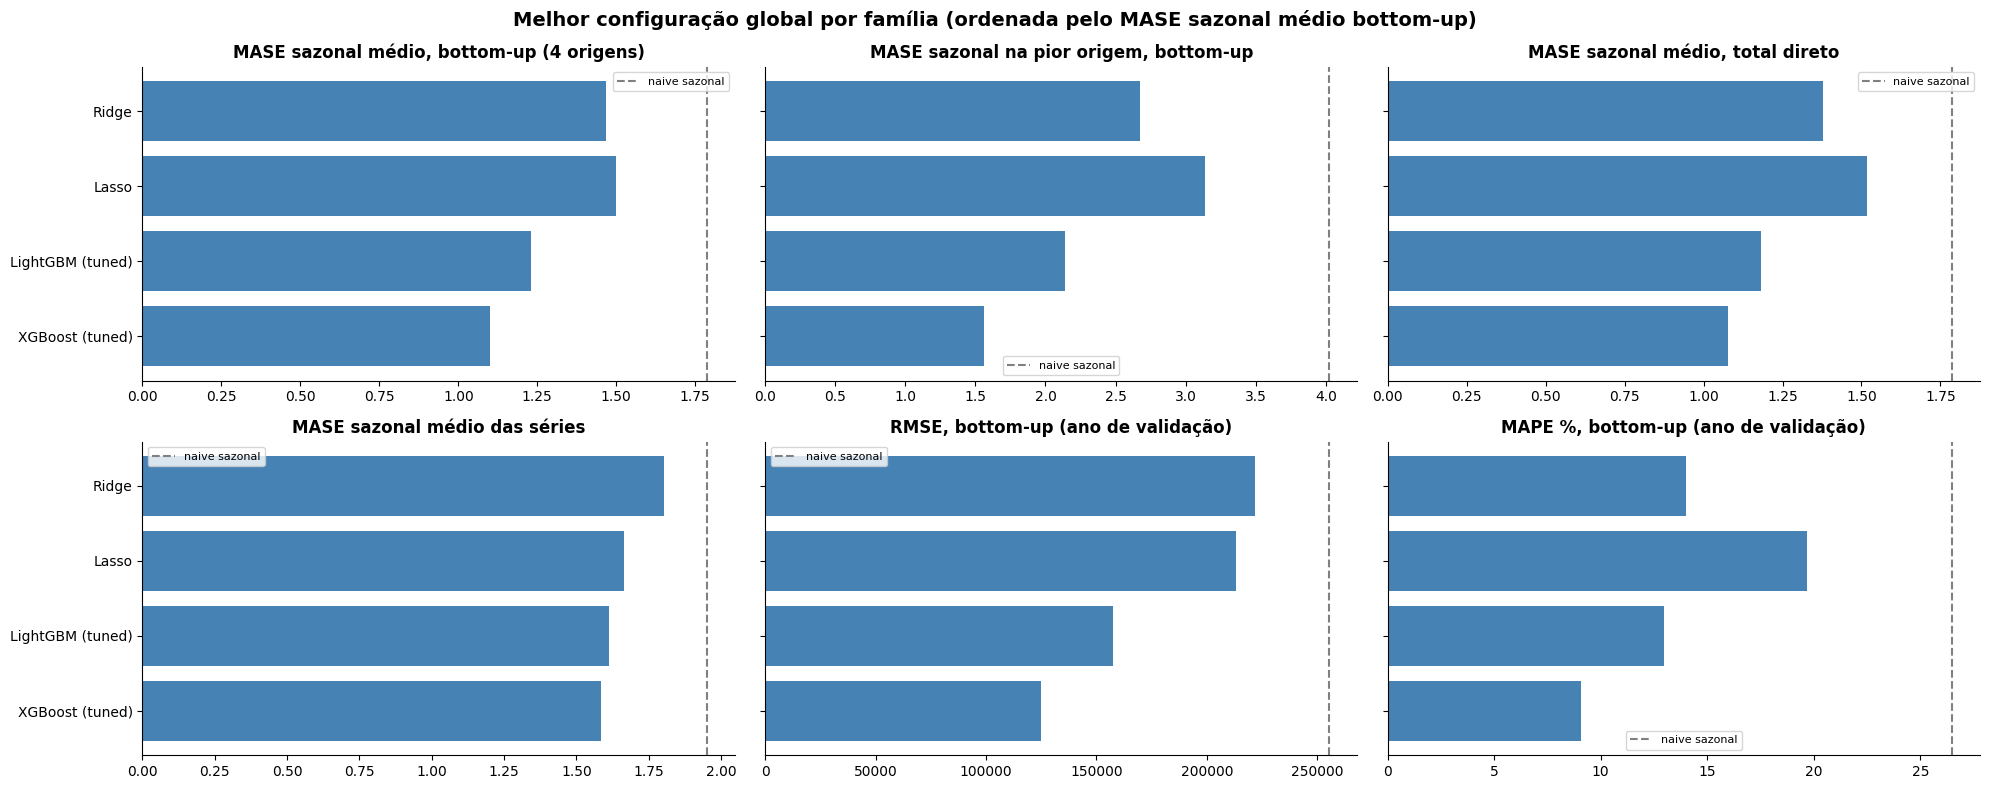

,family,transform,window,covid_rows,strategy,feature_set,tuned,MASE_mean,MASE_worst,MASE_post,MASE_direct_mean,MASE_series_mean,n_origins,RMSE,MAE,MAPE,R2,MASE,Forecast Bias,n_trees,alpha,alpha_at_edge
0,ridge,mean_scale,all,remove,recursive,lags+rolling+domain+static+cal_cat,False,1.467,2.677,1.969,1.380,1.802,4,221859.836,139121.593,14.002,0.552,2.677,18.759,NaN,1.000,0/4
1,lasso,seasonal_log_diff,all,remove,recursive,lags+rolling+domain+static+cal_cat,False,1.500,3.141,1.924,1.517,1.665,4,213299.200,163222.367,19.696,0.586,3.141,22.133,NaN,0.007,0/4
2,lightgbm,seasonal_log_diff,last_6y,keep,recursive,lags+rolling+domain+static+cal_cat,True,1.231,2.136,1.471,1.183,1.613,4,157293.008,111011.882,12.980,0.775,2.136,14.368,45.0,NaN,None
3,xgboost,seasonal_log_diff,last_6y,keep,recursive,lags+growth+rolling+domain+static+cal_fourier,True,1.101,1.563,1.253,1.077,1.584,4,125101.593,81214.072,9.051,0.858,1.563,9.463,46.0,NaN,None


In [17]:
best_per_family = ranked.groupby('family', sort=False).first()
best_per_family = best_per_family.reindex([
    f for f in FAMILIES if f in best_per_family.index
]).reset_index()
best_per_family['label'] = best_per_family['family'].map(FAMILY_NAMES) + np.where(
    best_per_family['tuned'], ' (tuned)', ''
)

BAR_METRICS = [
    'MASE_mean',
    'MASE_worst',
    'MASE_direct_mean',
    'MASE_series_mean',
    'RMSE',
    'MAPE',
]
METRIC_LABELS = {
    'MASE_mean': f'MASE sazonal médio, bottom-up ({len(ORIGINS)} origens)',
    'MASE_worst': 'MASE sazonal na pior origem, bottom-up',
    'MASE_direct_mean': 'MASE sazonal médio, total direto',
    'MASE_series_mean': 'MASE sazonal médio das séries',
    'RMSE': 'RMSE, bottom-up (ano de validação)',
    'MAPE': 'MAPE %, bottom-up (ano de validação)',
}

fig, axes = plt.subplots(2, 3, figsize=(20, 8), sharey=True)
fig.suptitle(
    'Melhor configuração global por família (ordenada pelo MASE sazonal médio bottom-up)',
    fontsize=14,
    fontweight='bold',
)
for ax, col in zip(axes.flat, BAR_METRICS):
    ax.barh(
        best_per_family['label'][::-1], best_per_family[col][::-1], color='steelblue'
    )
    ax.axvline(
        float(baselines.loc['seasonal_naive', col]),
        color='grey',
        linestyle='--',
        label='naive sazonal',
    )
    ax.set_title(METRIC_LABELS[col], fontweight='bold')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

best_per_family[
    [*PARAM_KEYS, 'tuned', *AGG_METRICS, *METRICS, 'n_trees', 'alpha', 'alpha_at_edge']
].round(3)

### Top 10 Configurações — Previsões de Validação do Total


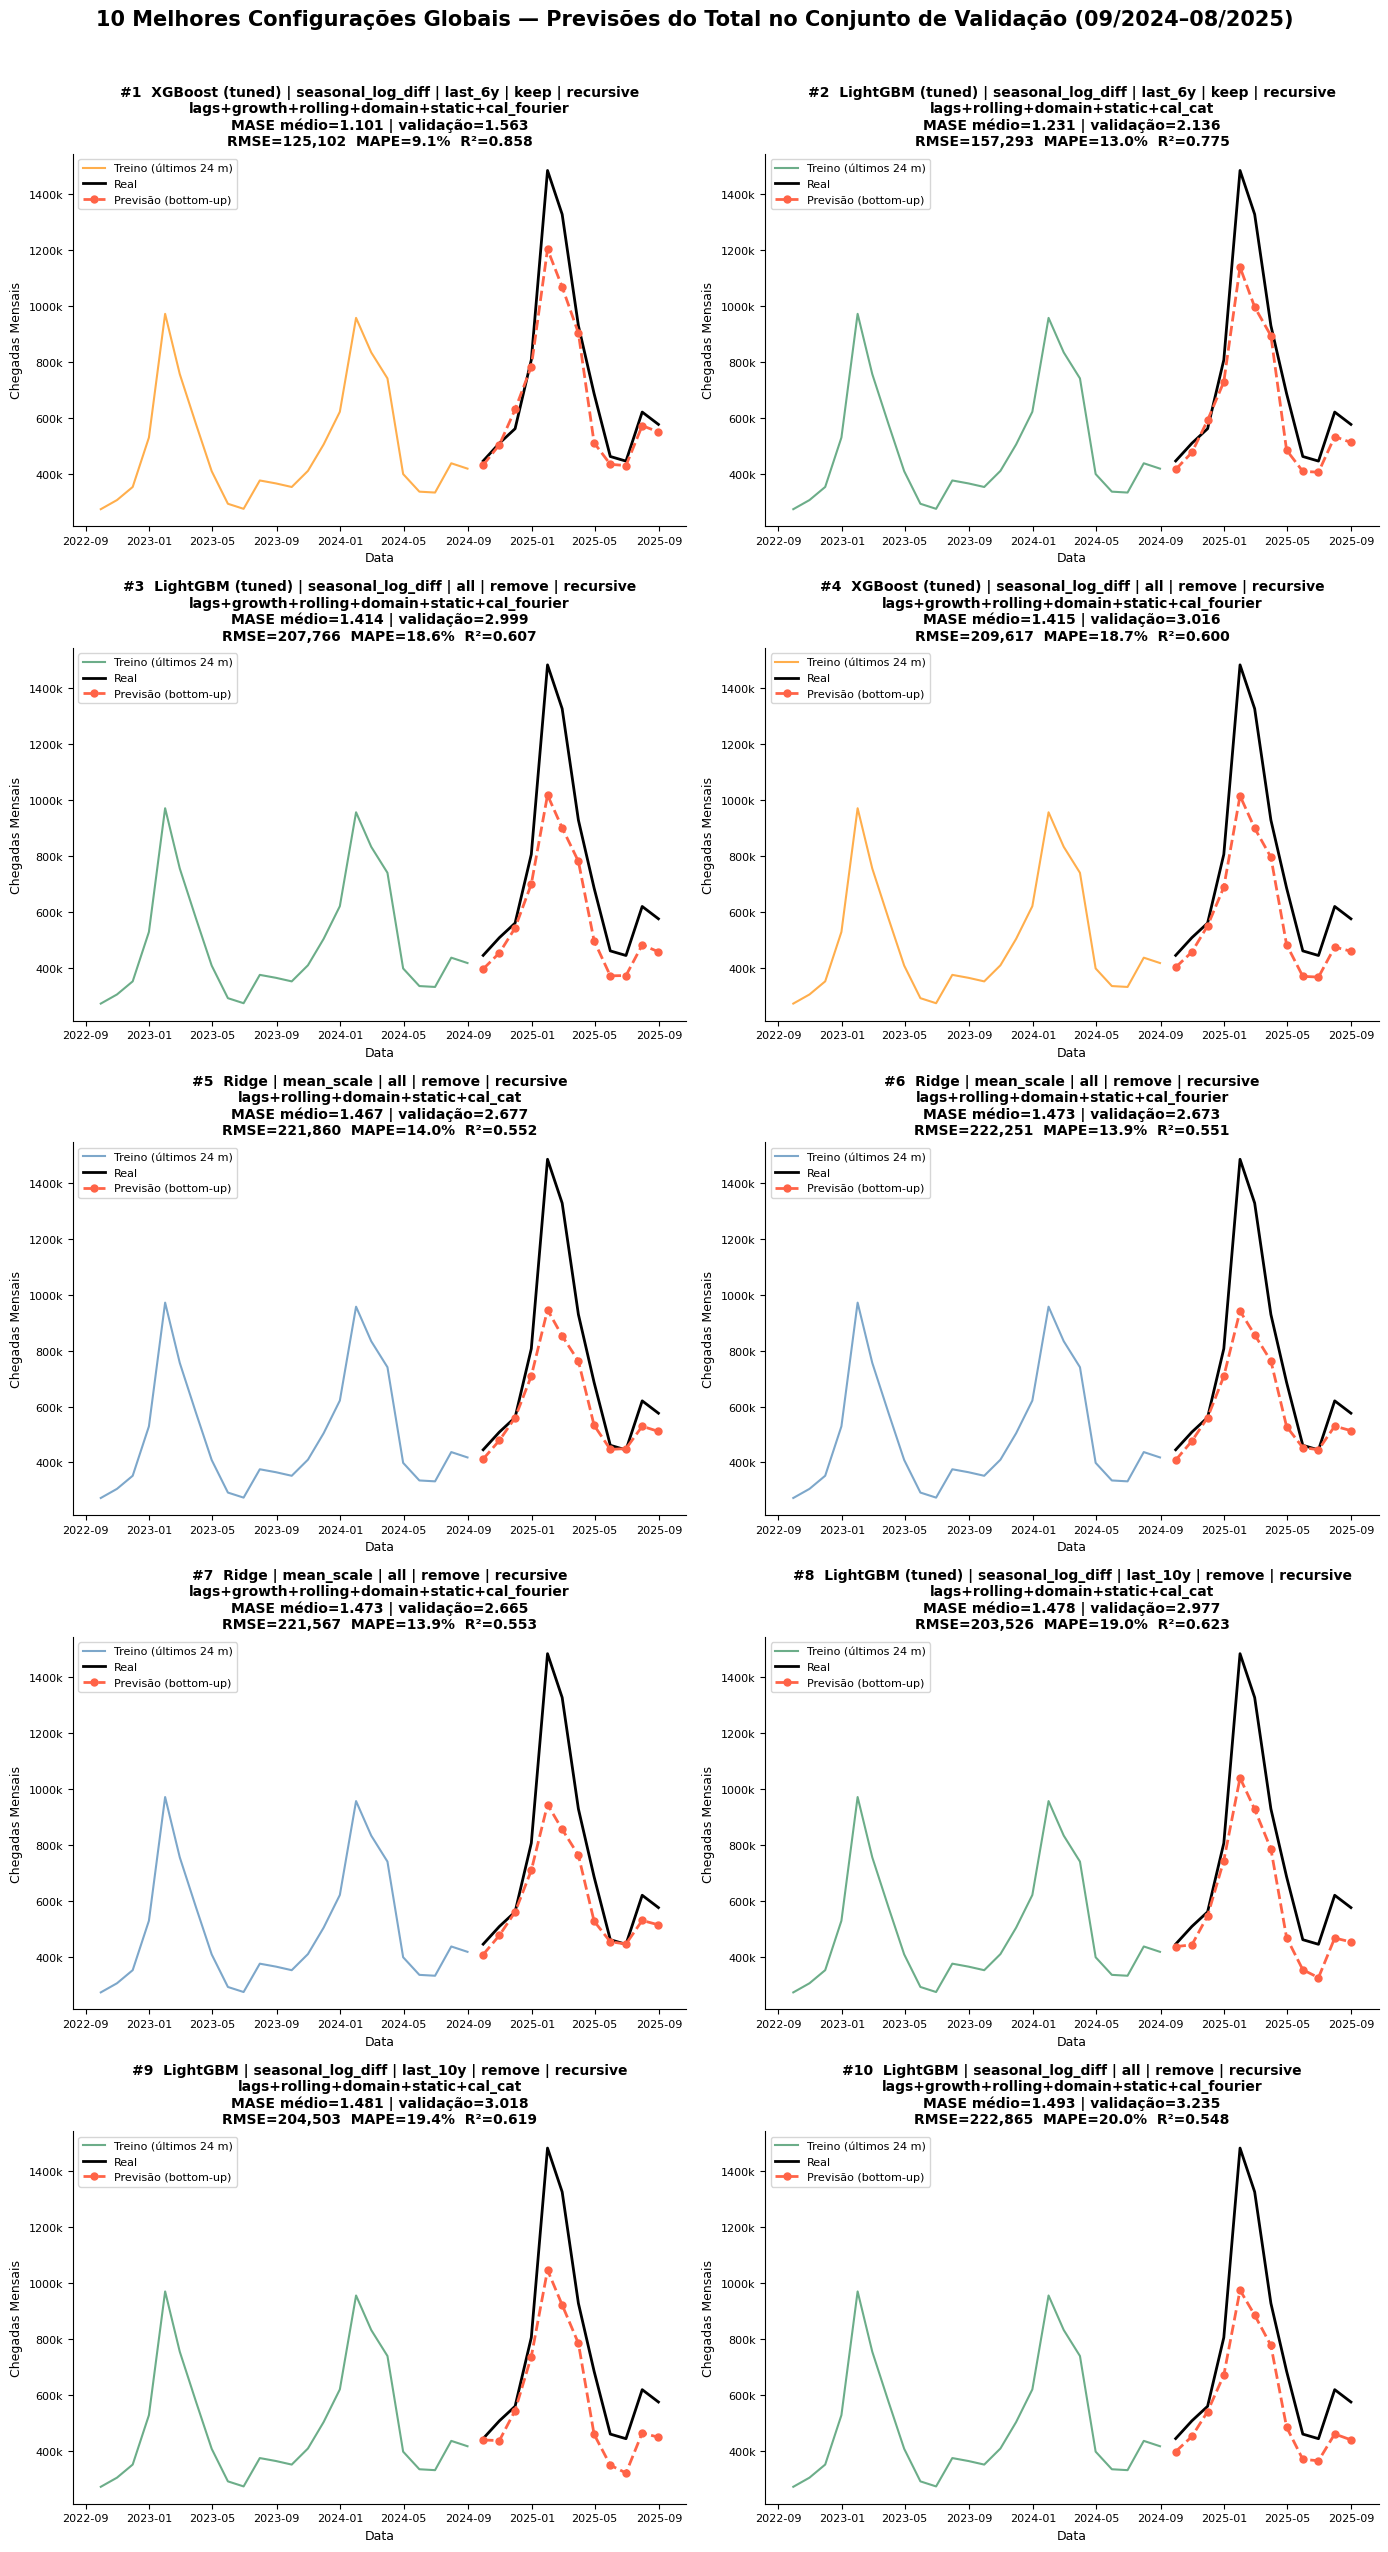

In [18]:
FAMILY_COLORS = {
    'ridge': 'steelblue',
    'lasso': 'mediumpurple',
    'lightgbm': 'seagreen',
    'xgboost': 'darkorange',
}
TOP_N_FORECASTS = 10

top10 = ranked.head(TOP_N_FORECASTS)
val_total = panel_wide.loc[val_dates_at(LATEST_ORIGIN), 'total']
train_plot = panel_wide.loc[:TRAIN_END, 'total'].iloc[-24:]

fig, axes = plt.subplots(5, 2, figsize=(14, 26))
fig.suptitle(
    f'10 Melhores Configurações Globais — Previsões do Total no Conjunto de Validação '
    f'({val_total.index[0]:%m/%Y}–{val_total.index[-1]:%m/%Y})',
    fontsize=15,
    fontweight='bold',
)

for i, (ax, (_, row)) in enumerate(zip(axes.flat, top10.iterrows())):
    ax.plot(
        train_plot.index,
        train_plot.values,
        label='Treino (últimos 24 m)',
        linewidth=1.5,
        color=FAMILY_COLORS[row['family']],
        alpha=0.7,
    )
    ax.plot(
        val_total.index, val_total.values, label='Real', linewidth=2, color='black'
    )
    ax.plot(
        val_total.index,
        row['prediction'],
        label='Previsão (bottom-up)',
        linewidth=2,
        linestyle='--',
        color='tomato',
        marker='o',
        markersize=5,
    )
    ax.set_title(
        f'#{i + 1}  {FAMILY_NAMES[row["family"]]}'
        f'{" (tuned)" if row["tuned"] else ""} | '
        f'{row["transform"]} | '
        f'{row["window"]} | {row["covid_rows"]} | {row["strategy"]}\n'
        f'{row["feature_set"]}\n'
        f'MASE médio={row["MASE_mean"]:.3f} | validação={row["MASE"]:.3f}\n'
        f'RMSE={row["RMSE"]:,.0f}  MAPE={row["MAPE"]:.1f}%  R²={row["R2"]:.3f}',
        fontsize=10,
        fontweight='bold',
    )
    ax.set_xlabel('Data', fontsize=9)
    ax.set_ylabel('Chegadas Mensais', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1000)}k'))
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

for ax in axes.flat[len(top10) :]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### A Melhor Configuração, Série por Série


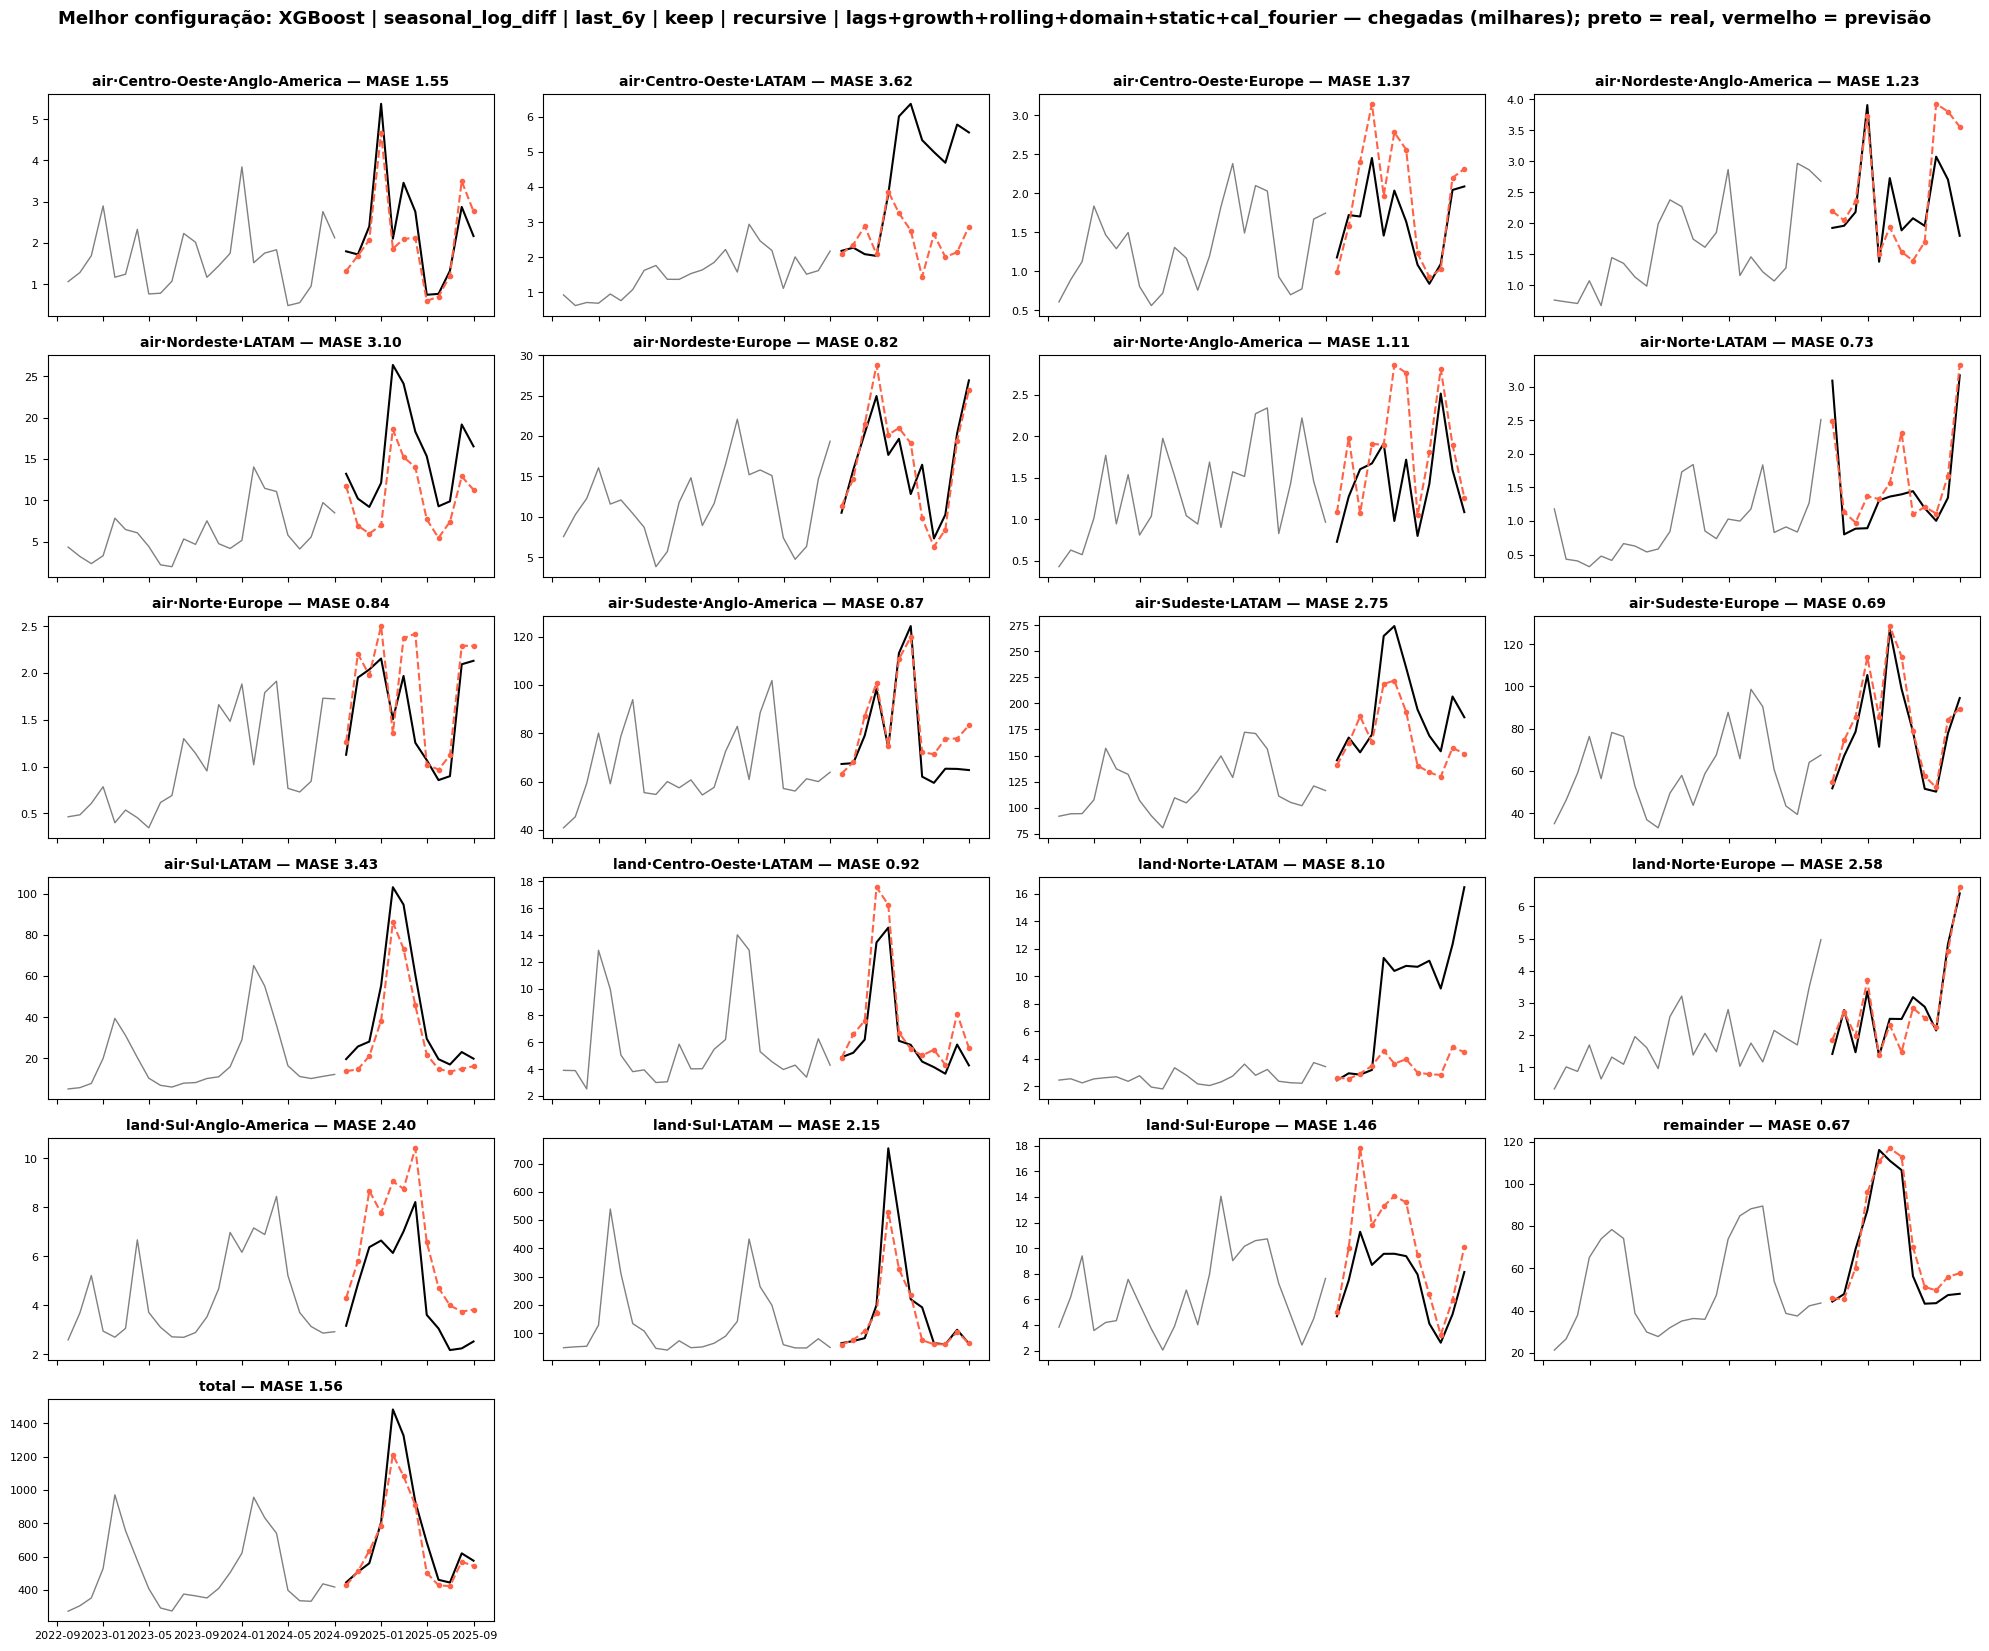

In [19]:
best = ranked.iloc[0]
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(20, 2.8 * n_rows), sharex=True)
for ax, series_id in zip(axes.flat, SERIES):
    history = panel_wide.loc[:TRAIN_END, series_id].iloc[-24:]
    actual = panel_wide.loc[val_total.index, series_id]
    ax.plot(history.index, history / 1e3, color='grey', linewidth=1)
    ax.plot(actual.index, actual / 1e3, color='black', linewidth=1.5)
    ax.plot(
        actual.index,
        best['forecast'][series_id] / 1e3,
        color='tomato',
        linestyle='--',
        marker='o',
        markersize=3,
    )
    ax.set_title(
        f'{series_id} — MASE {best["series_mase"][series_id]:.2f}',
        fontsize=10,
        fontweight='bold',
    )
    ax.tick_params(labelsize=8)
for ax in axes.flat[len(SERIES) :]:
    ax.set_visible(False)
fig.suptitle(
    f'Melhor configuração: {row_config(best).label} — chegadas (milhares); '
    'preto = real, vermelho = previsão',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 9. Heatmaps das Combinações


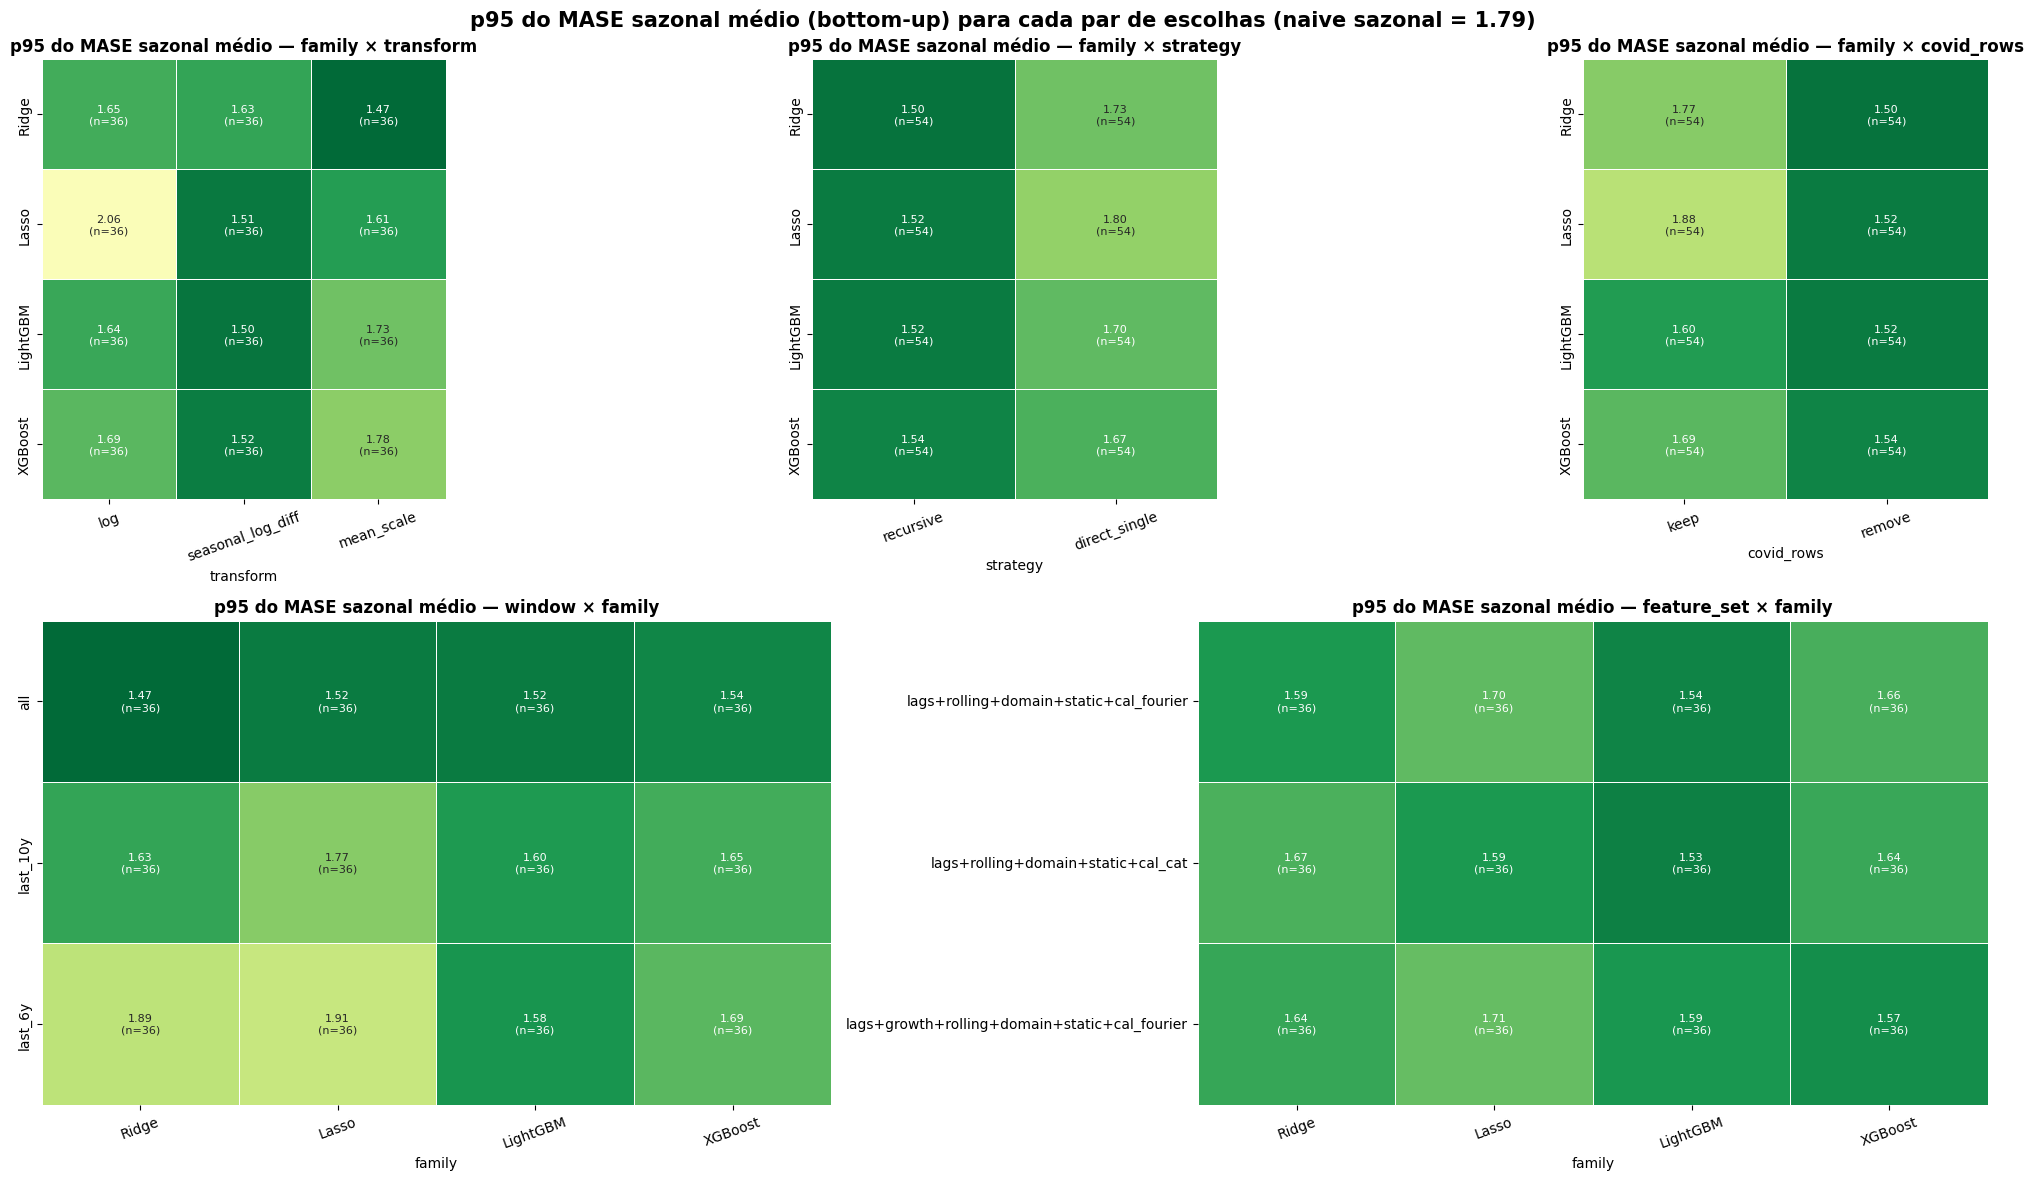

In [20]:
ORDERS = {
    'family': FAMILIES,
    'transform': TARGET_TRANSFORMS,
    'window': list(WINDOWS),
    'covid_rows': COVID_ROWS,
    'strategy': STRATEGIES,
    'feature_set': [set_label(s) for s in FEATURE_SETS],
}
HEATMAP_LAYOUT = [
    # (rows, columns, grid position)
    ('family', 'transform', (0, slice(0, 2))),
    ('family', 'strategy', (0, slice(2, 4))),
    ('family', 'covid_rows', (0, slice(4, 6))),
    ('window', 'family', (1, slice(0, 3))),
    ('feature_set', 'family', (1, slice(3, 6))),
]
MASE_LABEL_CAP = 10
P95_QUANTILE = 0.05  # p95: the value only the best 5% of a cell's configurations beat
grid_ranked = ranked[~ranked['tuned']]


def p95(values):
    return values.quantile(P95_QUANTILE)


def mase_label(value, count):
    if pd.isna(value):
        return ''
    shown = f'>{MASE_LABEL_CAP}' if value > MASE_LABEL_CAP else f'{value:.2f}'
    return f'{shown}\n(n={int(count)})'


def p95_mase_pivot(rows, columns):
    """p95 of the mean seasonal MASE per cell, and the configurations per cell."""
    frames = [
        grid_ranked.pivot_table(
            index=rows, columns=columns, values='MASE_mean', aggfunc=aggfunc
        ).reindex(
            index=[v for v in ORDERS[rows] if v in grid_ranked[rows].unique()],
            columns=[v for v in ORDERS[columns] if v in grid_ranked[columns].unique()],
        )
        for aggfunc in (p95, 'count')
    ]
    if rows == 'family':
        frames = [frame.rename(index=FAMILY_NAMES) for frame in frames]
    if columns == 'family':
        frames = [frame.rename(columns=FAMILY_NAMES) for frame in frames]
    pivot, counts = frames
    labels = pd.DataFrame(
        [
            [mase_label(v, n) for v, n in zip(values, ns)]
            for values, ns in zip(pivot.to_numpy(), counts.to_numpy())
        ],
        index=pivot.index,
        columns=pivot.columns,
    )
    return pivot, labels


fig = plt.figure(figsize=(20, 12))
grid = fig.add_gridspec(2, 6, height_ratios=[1, 1.1])
for rows, columns, (r, c) in HEATMAP_LAYOUT:
    ax = fig.add_subplot(grid[r, c])
    pivot, labels = p95_mase_pivot(rows, columns)
    sns.heatmap(
        pivot,
        annot=labels,
        fmt='',
        annot_kws={'fontsize': 8},
        cmap='RdYlGn_r',
        vmin=grid_ranked['MASE_mean'].min(),
        vmax=BASELINE_MASE * 1.5,
        linewidths=0.4,
        cbar=False,
        ax=ax,
    )
    ax.set_title(f'p95 do MASE sazonal médio — {rows} × {columns}', fontweight='bold')
    ax.set_xlabel(columns)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelrotation=20)
fig.suptitle(
    'p95 do MASE sazonal médio (bottom-up) para cada par de escolhas '
    f'(naive sazonal = {BASELINE_MASE:.2f})',
    fontsize=15,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

## 11. Importância das Features da Melhor Configuração por Família


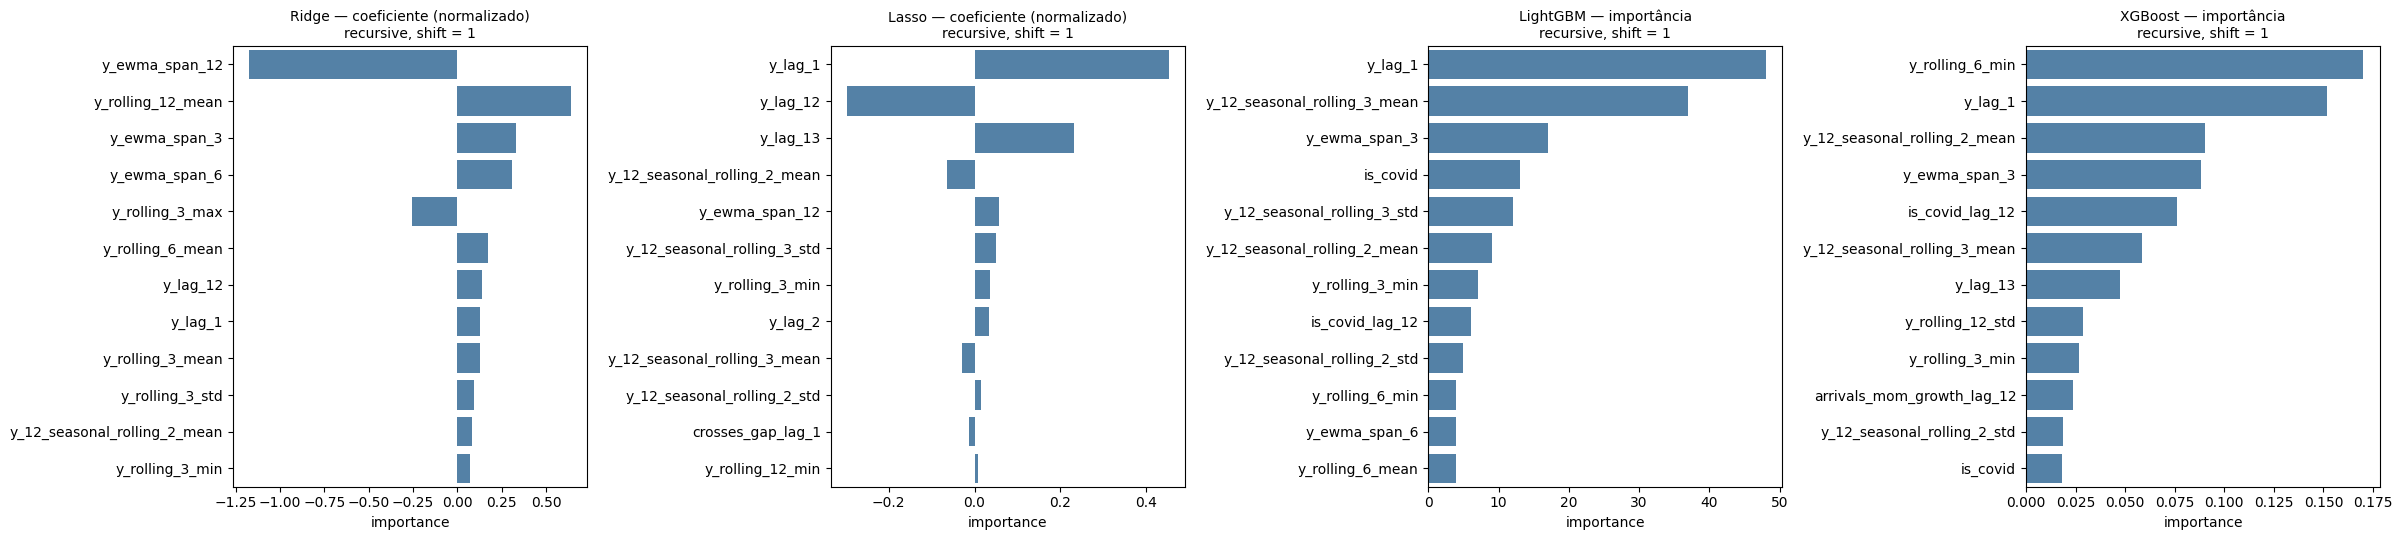

In [21]:
def refit(row):
    config = row_config(row)
    tree_params = row['tree_params'] if isinstance(row['tree_params'], dict) else None
    setup = setup_for(config, LATEST_ORIGIN)
    shift = 1 if config.strategy == 'recursive' else HORIZON
    frame = with_future_rows(setup['history'], val_dates_at(LATEST_ORIGIN))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model, feature_config, _ = fit_for_shift(
            config, setup, frame, shift, tree_params
        )
    return config, shift, model, feature_config


best_models = {row['family']: refit(row) for _, row in best_per_family.iterrows()}

TOP_FEATURES = 12
fig, axes = plt.subplots(1, len(best_models), figsize=(24, 5.5))
for ax, family in zip(np.atleast_1d(axes), best_models):
    config, shift, model, _ = best_models[family]
    importance = model.feature_importance().head(TOP_FEATURES)
    sns.barplot(data=importance, x='importance', y='feature', ax=ax, color='steelblue')
    kind = 'importância' if family in TREE_FAMILIES else 'coeficiente (normalizado)'
    ax.set_title(
        f'{FAMILY_NAMES[family]} — {kind}\n{config.strategy}, shift = {shift}',
        fontsize=10,
    )
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

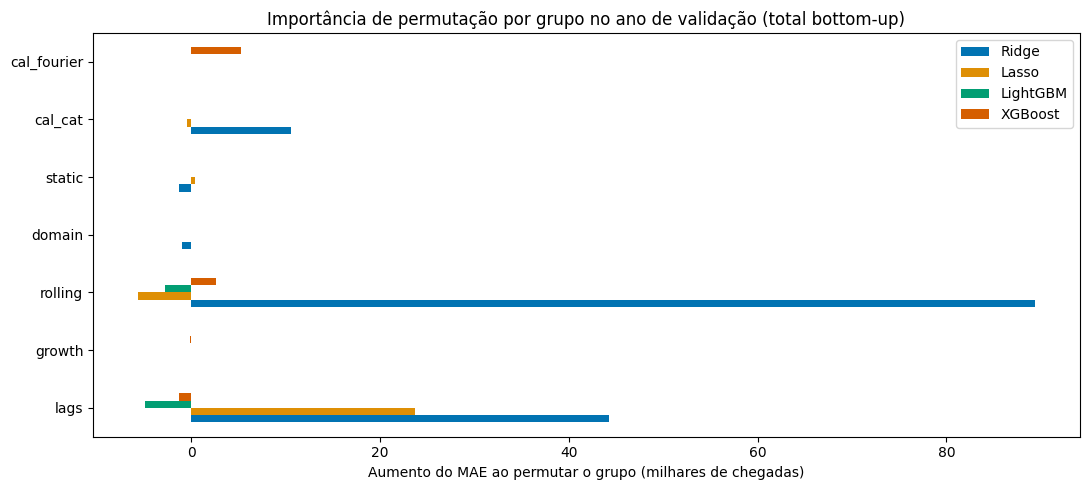

,Ridge,Lasso,LightGBM,XGBoost
lags,44261.0,23740.0,-4941.0,-1295.0
growth,NaN,NaN,NaN,-180.0
rolling,89398.0,-5662.0,-2825.0,2569.0
domain,-934.0,-16.0,0.0,0.0
static,-1274.0,440.0,0.0,-32.0
cal_cat,10584.0,-405.0,0.0,NaN
cal_fourier,NaN,NaN,NaN,5311.0


In [22]:
N_REPEATS = 20


def group_permutation_importance(  # noqa: PLR0913, PLR0914, PLR0917
    config, shift, model, feature_config, n_repeats=N_REPEATS
):
    """Bottom-up validation MAE increase when the columns of a group are shuffled."""
    setup = setup_for(config, LATEST_ORIGIN)
    val_months = val_dates_at(LATEST_ORIGIN)
    observed = pd.concat(
        [setup['history'], panel[panel['date'].isin(val_months)]], ignore_index=True
    )
    for series_id, transformer in setup['transformers'].items():
        is_val = (observed[TS_ID] == series_id) & observed['date'].isin(val_months)
        values = observed.loc[observed[TS_ID] == series_id].set_index('date')[TARGET]
        if isinstance(transformer, SeasonalLog1pDiffTarget):
            z = np.log1p(values) - np.log1p(values).shift(SEASONAL_PERIOD)
        else:
            z = transformer.transform(values)
        observed.loc[is_val, Y] = z.loc[val_months].to_numpy()
    features, groups = build_features(observed, shift)
    rows = features[features['date'].isin(val_months)].reset_index(drop=True)
    actual = panel_wide.loc[val_months, 'total'].to_numpy()

    def mae_of(frame):
        predicted = to_arrivals(setup, predicted_frame(model, feature_config, frame))
        table = predicted.pivot_table(
            index='date', columns=TS_ID, values=TARGET, aggfunc='first'
        )
        return float(np.mean(np.abs(actual - table[BOTTOM_UP].sum(axis=1).to_numpy())))

    base = mae_of(rows)
    rng = np.random.default_rng(RANDOM_STATE)
    increases = {}
    for group in config.feature_set:
        scores = []
        for _ in range(n_repeats):
            shuffled = rows.copy()
            order = rng.permutation(len(rows))
            shuffled[groups[group]] = (
                rows[groups[group]].iloc[order].set_axis(rows.index)
            )
            scores.append(mae_of(shuffled) - base)
        increases[group] = np.mean(scores)
    return pd.Series(increases)


with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    permutation = (
        pd
        .DataFrame({
            FAMILY_NAMES[family]: group_permutation_importance(*best_models[family])
            for family in best_models
        })
        .reindex(GROUP_ORDER)
        .dropna(how='all')
    )

ax = (permutation / 1e3).plot.barh(figsize=(11, 5))
ax.set_title('Importância de permutação por grupo no ano de validação (total bottom-up)')
ax.set_xlabel('Aumento do MAE ao permutar o grupo (milhares de chegadas)')
plt.tight_layout()
plt.show()
permutation.round(0)

## 12. Salvar as Previsões de Validação da Melhor Configuração

As previsões agregadas da melhor configuração global são salvas como artefato `validation_forecasts.csv`
no MLflow para uso no notebook 10 (ensembling e stacking).


In [23]:
best = ranked.iloc[0]
best_config = row_config(best)
best_tree_params = (
    best['tree_params'] if isinstance(best['tree_params'], dict) else None
)
origin_results = evaluate_origins(best_config, best_tree_params)
assert all(r['error'] is None for r in origin_results)

best_forecasts = pd.concat(
    [
        pd.DataFrame({
            'origin': origin_label(r['origin']),
            'date': val_dates_at(r['origin']),
            'actual': panel_wide.loc[val_dates_at(r['origin']), 'total'].to_numpy(),
            'forecast': r['prediction'],  # bottom-up total
        })
        for r in origin_results
    ],
    ignore_index=True,
)
mase_mean = float(np.mean([r['MASE'] for r in origin_results]))
assert np.isclose(mase_mean, best['MASE_mean']), (mase_mean, best['MASE_mean'])


def log_validation_forecasts(approach, configuration, forecasts, mase_mean):
    """Log the best configuration's forecasts at every origin as an MLflow artifact."""
    with mlflow.start_run(
        run_name=f'BEST validation forecasts | {configuration}'[:250]
    ):
        mlflow.set_tags({'role': 'best_validation_forecasts', 'approach': approach})
        mlflow.log_params({
            'configuration': configuration[:500],
            'origins': ', '.join(sorted(forecasts['origin'].unique())),
            'horizon': HORIZON,
        })
        mlflow.log_metric('MASE_mean', mase_mean)
        mlflow.log_text(forecasts.to_csv(index=False), 'validation_forecasts.csv')
    print(f'{approach}: logged {len(forecasts)} forecasts of {configuration}')


label = best_config.label + (' | tuned' if best['tuned'] else '')
log_validation_forecasts('Global ML', label, best_forecasts, mase_mean)

Global ML: logged 48 forecasts of XGBoost | seasonal_log_diff | last_6y | keep | recursive | lags+growth+rolling+domain+static+cal_fourier | tuned


## Leitura dos Resultados
